[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tahermamun/AI-Energy-Consumption-Forecasting/blob/main/notebook/project_artefact.ipynb)

# **AI-Based Energy Consumption Forecasting for Sustainable Energy Management**
### **Module:** Essentials and Applications of Artificial Intelligence - UFCE3P-30-3
### Assessment 2 — Group Project

## **Section 1 - Introduction**
#### **1.1 Problem Statement:**

Electricity demand exhibits strong temporal variability across hours, days, seasons, and weather conditions. Accurate short-term forecasting is therefore essential for maintaining the real-time balance between electricity supply and demand.

Forecasting errors introduce significant operational risks. Over-generation leads to unnecessary fuel consumption and increased carbon emissions, while under-generation poses a more critical threat by increasing the risk of grid instability and potential blackouts. Furthermore, inaccurate demand estimation limits the effective integration of renewable energy sources, which require precise balancing due to their intermittent nature.

This project develops, compares, and critically evaluates artificial intelligence (AI)-based models for forecasting hourly electricity demand in the American Electric Power (AEP) service region. AEP is one of the largest regional transmission systems in North America, serving multiple states including Ohio, Indiana, and Michigan.

The objective is to achieve high forecasting accuracy while ensuring operational reliability and model interpretability for real-world energy management applications.


#### **1.2 Project Scope & Guardrails**
The project focuses specifically on short-term electricity demand forecasting and is designed with clearly defined boundaries to ensure methodological clarity.

| ✅ In Scope                                                         | ❌ Out of Scope                  |
| ------------------------------------------------------------------ | ------------------------------- |
| Hourly demand forecasting (2004–2018)                              | Full smart grid optimisation    |
| Weather impact analysis                                            | Renewable energy dispatch       |
| Model comparison (Baseline, Random Forest, XGBoost, optional LSTM) | National-level modelling        |
| Error and failure analysis                                         | Real-time production deployment |

*The scope is intentionally constrained to demand forecasting and does not attempt full grid optimisation, ensuring a focused and analytically rigorous study.*

#### **1.3 Core Research Questions**
---
> need to algn those according to project
1. Can hourly electricity demand be predicted with acceptable accuracy?
2. Which model provides the best balance between accuracy and simplicity?
3. Do weather variables significantly improve prediction performance?
4. Under which conditions does the model fail (e.g., extreme weather, holidays)?

This study is guided by the following research questions:

* Can hourly electricity demand be predicted with acceptable accuracy using AI models?
* Which model provides the best balance between accuracy and computational efficiency?
* Do weather variables significantly improve forecasting performance?
* Under which conditions does the model fail, particularly during extreme demand scenarios?
---

#### **1.4 Mathematical Formulation**

This is a **supervised autoregressive regression problem with exogenous inputs (ARX)**:

$$\hat{y}_{t+1} = f\left(\underbrace{y_{t-1}, y_{t-24}, y_{t-168}}_{\text{lag features}},\ \underbrace{hour_t, day_t, month_t}_{\text{time features}},\ \underbrace{temp_t, humidity_t, \ldots}_{\text{weather features}}\right) + \epsilon_t$$

where $y_t$ = electricity demand (MW), $f(\cdot)$ = the learned model, $\epsilon_t$ = irreducible error.





#### **1.5 Technical Setup**
This section establishes the computational environment required for model development and evaluation. All necessary libraries are imported, data sources are configured, and a fixed random seed is defined to ensure reproducibility.

The implementation uses Python-based machine learning libraries, including Scikit-learn for baseline and linear models, and XGBoost for advanced gradient boosting. These tools are widely adopted in modern forecasting applications due to their efficiency and strong predictive performance (Chen & Guestrin, 2016; Brownlee, 2020).

A dual-path data loading mechanism is implemented to support both local development (e.g., VS Code) and cloud-based execution (e.g., Google Colab) using GitHub-hosted datasets. This ensures flexibility and consistency across different development environments.

Additionally, reproducibility is enforced by fixing the random seed, which is essential for ensuring consistent experimental results in machine learning workflows.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, random
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
warnings.filterwarnings("ignore")

# Metrics & Preprocessing ---
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


# Model Imports 

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Global Configuration
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# -------- CONFIG DATESET--------
USE_LOCAL = False   # 🔁 Change to True if using VS Code local files

# -------- PATHS --------
if USE_LOCAL:
    # Local (VS Code users)
    ENERGY_PATH  = "data/AEP_hourly.csv"
    WEATHER_PATH = "data/noaa_weather_columbus.csv"
else:
    # GitHub RAW links (Colab + shared usage)
    ENERGY_PATH  = "https://raw.githubusercontent.com/tahermamun/AI-Energy-Consumption-Forecasting/main/data/AEP_hourly.csv"
    WEATHER_PATH = "https://raw.githubusercontent.com/tahermamun/AI-Energy-Consumption-Forecasting/main/data/noaa_weather_columbus.csv"



# Plot style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
# ── Plot styling ──────────────────────────────────────────────
BLUE="#2E86AB"; ORANGE="#E07B54"; GREEN="#4CAF50"
RED="#E53935";  PURPLE="#7B1FA2"; GREY="#546E7A"; DARK="#1A1A2E"

# Optional Libraries
try:
    import statsmodels.api as sm
    print("statsmodels ready.")
except ImportError:
    sm = None
    print("statsmodels not available.")

try:
    import tensorflow as tf
    tf.random.set_seed(RANDOM_SEED)
    print("TensorFlow 2.x ready.")
except ImportError:
    tf = None
    print("TensorFlow not available.")

# Status
print("\nEnvironment ready.")
print(f"  Energy  : {ENERGY_PATH}")
print(f"  Weather : {WEATHER_PATH}")
print(f"  Seed    : {RANDOM_SEED}")

statsmodels ready.
TensorFlow not available.

Environment ready.
  Energy  : https://raw.githubusercontent.com/tahermamun/AI-Energy-Consumption-Forecasting/main/data/AEP_hourly.csv
  Weather : https://raw.githubusercontent.com/tahermamun/AI-Energy-Consumption-Forecasting/main/data/noaa_weather_columbus.csv
  Seed    : 42


## **Section 2 — Data Understanding**

Data understanding is not a descriptive preliminary step; it determines whether the forecasting pipeline rests on valid inputs. In short-horizon load forecasting, model reliability depends not only on algorithm choice but also on the temporal consistency, coverage, and alignment of the underlying series (Hyndman and Athanasopoulos, 2021). This section therefore evaluates whether the hourly AEP demand series is suitable as the forecasting target, whether the weather data is defensible as an exogenous predictor set, and whether any structural mismatch is identified before preprocessing.

#### **2.2 Data Loading**

Both datasets were loaded in Section 1.5, under the Technical Setup section.
The electricity demand and weather datasets are loaded separately and kept unmerged at this stage. This is methodologically necessary because early merging can hide source-specific problems such as duplicated timestamps, missing hours, or incompatible time indices. Maintaining separation also preserves the distinction between the target variable and the explanatory predictors, which is important for transparent modelling and evaluation (Hong and Fan, 2016).



#### **2.2.1 Energy Dataset Overview**

The energy file (`AEP_hourly.csv`) contains hourly megawatt (MW) readings for the AEP service area and serves as the forecasting target. Its hourly resolution is appropriate for short-term operational forecasting, while its long time span provides sufficient depth to capture daily, weekly, and seasonal variation.

The observed load range appears plausible for a regional electricity system, which supports the credibility of the target series. However, because the dataset depends on a single timestamp field, any duplicated hours or daylight saving discontinuities would directly affect lag and rolling features. Temporal integrity must therefore be tested rather than assumed.

In [2]:
energy_raw  = pd.read_csv(ENERGY_PATH)

print("ENERGY DATASET — AEP_hourly.csv")
print(f"  Shape   : {energy_raw.shape[0]:,} rows × {energy_raw.shape[1]} columns")
print(f"  Columns : {list(energy_raw.columns)}")
print(f"  MW range: {energy_raw['AEP_MW'].min():,.0f} – {energy_raw['AEP_MW'].max():,.0f} MW")
display(energy_raw.head(3))
display(energy_raw.describe())

ENERGY DATASET — AEP_hourly.csv
  Shape   : 121,273 rows × 2 columns
  Columns : ['Datetime', 'AEP_MW']
  MW range: 9,581 – 25,695 MW


,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0


,AEP_MW
count,121273.000000
mean,15499.513717
std,2591.399065
min,9581.000000
25%,13630.000000
50%,15310.000000
75%,17200.000000
max,25695.000000


#### **2.2.2 Weather Dataset Overview**

The weather file (`noaa_weather_columbus.csv`) provides hourly meteorological observations and serves as the exogenous predictor set. Its main value lies in explaining variation that historical load alone may not capture, particularly where demand changes in response to environmental conditions.

Temperature is the most theoretically important variable because electricity demand typically rises under both extreme heat and extreme cold due to cooling and heating effects (Hong and Fan, 2016). 

In [3]:
weather_raw = pd.read_csv(WEATHER_PATH)

print("WEATHER DATASET — noaa_weather_columbus.csv")
print(f"  Shape   : {weather_raw.shape[0]:,} rows × {weather_raw.shape[1]} columns")
print(f"  Columns : {list(weather_raw.columns)}")
print(f"  Temp range: {weather_raw['temp_C'].min():.1f}°C – {weather_raw['temp_C'].max():.1f}°C")
print("=" * 58)
display(weather_raw.head(3))
display(weather_raw.describe())


WEATHER DATASET — noaa_weather_columbus.csv
  Shape   : 127,896 rows × 6 columns
  Columns : ['datetime', 'temp_C', 'humidity', 'wind_speed', 'pressure', 'precipitation']
  Temp range: -28.9°C – 38.1°C


,datetime,temp_C,humidity,wind_speed,pressure,precipitation
0,2004-01-01 00:00:00,0.1,86,7.6,998.2,0.0
1,2004-01-01 01:00:00,-0.5,89,7.9,998.5,0.0
2,2004-01-01 02:00:00,-1.0,90,8.6,999.1,0.0


,temp_C,humidity,wind_speed,pressure,precipitation
count,127896.000000,127896.000000,127896.000000,127896.000000,127896.000000
mean,11.698056,69.771142,11.978831,990.293792,0.122237
std,11.005152,17.242768,6.104409,6.582720,0.494623
min,-28.900000,17.000000,0.000000,960.400000,0.000000
25%,2.900000,57.000000,7.500000,986.400000,0.000000
50%,12.900000,71.000000,10.800000,990.400000,0.000000
75%,20.700000,84.000000,15.500000,994.300000,0.000000
max,38.100000,100.000000,53.900000,1015.700000,28.400000


#### **2.2.3 Data Coverage & Time Range**

- **Energy:** October 2004 – August 2018  
- **Weather:** January 2004 – August 2018  
- **Overlap retained for modelling:** October 2004 – August 2018  

The datasets overlap substantially but not perfectly. This is methodologically important because only observations with both valid load and weather information can support supervised forecasting. The common overlap therefore defines the usable modelling horizon.

Alignment must be verified at the hourly level, not only by calendar range, because timestamp offsets or daylight saving mismatch would distort lag structure and later validation (Bergmeir and Benítez, 2012). The long shared window is a strength, but it also means that later modelling should be cautious about assuming full stationarity across the entire period.

In [4]:
print(energy_raw["Datetime"].min(), energy_raw["Datetime"].max())
print(weather_raw["datetime"].min(), weather_raw["datetime"].max())

2004-10-01 01:00:00 2018-08-03 00:00:00
2004-01-01 00:00:00 2018-08-03 23:00:00


## **2.3 Data Quality Audit & Profiling**

An automated audit using `ydata-profiling` was used to produce a reproducible overview of schema, missingness, distributions, and basic structural issues. Its purpose is not to replace analysis, but to identify the issues that could weaken later modelling.

The profiling results are interpreted critically. In time-series forecasting, static summaries and correlations can be misleading because they ignore temporal dependence and may conceal duplicated hours, clustered missingness, or regime shifts (Hyndman and Athanasopoulos, 2021). The audit is therefore used to answer targeted questions: whether timestamps are monotonic, whether duplicated indices exist, whether missingness is isolated or contiguous, and whether any implausible patterns suggest recording problems.

This stage is important because different data problems require different responses. Small isolated gaps may be manageable, whereas long missing blocks or temporal discontinuities risk introducing artificial structure into the data. The purpose of the audit is therefore to determine what must be corrected before a defensible forecasting model can be built.



In [5]:
# run once to install the profiling tool
%pip install ydata-profiling -q

Note: you may need to restart the kernel to use updated packages.


In [6]:
from ydata_profiling import ProfileReport

# Setup paths (robust)
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
REPORT_DIR = os.path.join(BASE_DIR, "y_report")
os.makedirs(REPORT_DIR, exist_ok=True)

# Function to generate report
def generate_report(df, name):
    report_path = os.path.join(REPORT_DIR, f"{name}.html")
    
    if not os.path.exists(report_path):
        print(f"Generating {name} report...")
        
        profile = ProfileReport(
            df,
            title=f"{name} Data Audit",
            minimal=True
        )
        
        profile.to_file(report_path)
        print(f"Saved: {report_path}")
    else:
        print(f"{name} report already exists.")

# Generate reports
generate_report(energy_raw, "aep_data_audit")
generate_report(weather_raw, "weather_data_audit")

aep_data_audit report already exists.
weather_data_audit report already exists.


## **Section 3 — Data Cleaning, Preprocessing and Integration**

In time-series forecasting, preprocessing is not a cosmetic step; it determines whether the temporal structure required for lag features, rolling statistics, and chronological validation remains valid. For this reason, the decisions in this section are justified by their effect on forecasting integrity rather than by general notions of data tidiness (Hyndman and Athanasopoulos, 2021).

#### **3.1 Data Cleaning Strategy**

The cleaning strategy is guided by one principle: the hourly time index must remain reliable. In forecasting, rows are not interchangeable, because the meaning of a lag or rolling window depends entirely on correct temporal order. Three priorities therefore shape preprocessing:

- **Timestamp integrity** — datetime fields must be converted and ordered correctly.
- **Index continuity** — duplicated or missing hours must be identified because they affect temporal features directly.
- **Retention of meaningful extremes** — genuine high or low values should be preserved where they may carry predictive signal, particularly in weather-sensitive demand forecasting (Hong and Fan, 2016).

A deliberate asymmetry is applied between the two data sources. The energy series, as the forecasting target, is held to stricter continuity requirements because errors in the target directly affect model learning. The weather series is cleaned more lightly, since its purpose is to contribute explanatory signal rather than define the supervised outcome.

#### **3.2 Energy Data Cleaning**

The energy dataset is cleaned more strictly because it forms the target series. Any temporal defect in the target would directly distort lag features, rolling statistics, and model evaluation.

- **Datetime conversion** ensures the series is interpreted chronologically rather than lexicographically.
- **Duplicate timestamp handling** addresses repeated hours associated with daylight saving time. These duplicates are grouped and averaged so that a single hourly index can be preserved without arbitrarily discarding one record.
- **Hourly index restoration** makes the time structure explicit by reindexing the series to a complete hourly range.
- **Bounded forward filling** is used only for short gaps, reflecting the assumption that load is locally persistent over brief periods. Longer gaps are not treated the same way, as this would risk fabricating unrealistic flat demand patterns (Kazijevs and Samad, 2023).

The result is a continuous, duplicate-free hourly target series suitable for supervised forecasting.



In [7]:
# Energy Data 
energy_df = energy_raw.copy()
energy_df["Datetime"] = pd.to_datetime(energy_df["Datetime"])

# Average DST duplicates
energy_df = (energy_df.groupby("Datetime")["AEP_MW"]
                       .mean()
                       .reset_index()
                       .sort_values("Datetime")
                       .set_index("Datetime"))

energy_df.columns = ["load_MW"]

# Fill genuine gaps
full_idx = pd.date_range(
    energy_df.index.min(),
    energy_df.index.max(),
    freq="h"
)

energy_df = energy_df.reindex(full_idx).ffill(limit=3)
energy_df.index.name = "Datetime"

# Report
print("ENERGY — Post-Cleaning Report")
print(f"  Date range  : {energy_df.index.min().date()} → {energy_df.index.max().date()}")
print(f"  Total hours : {len(energy_df):,}")
print(f"  Missing     : {energy_df.isnull().sum().values[0]}")
print(f"  Min load    : {energy_df['load_MW'].min():,.0f} MW")
print(f"  Max load    : {energy_df['load_MW'].max():,.0f} MW")
print(f"  Mean load   : {energy_df['load_MW'].mean():,.0f} MW")

ENERGY — Post-Cleaning Report
  Date range  : 2004-10-01 → 2018-08-03
  Total hours : 121,296
  Missing     : 0
  Min load    : 9,581 MW
  Max load    : 25,695 MW
  Mean load   : 15,499 MW


#### **3.3 Weather Data Cleaning**

The weather data enters the pipeline as an exogenous predictor set, so the objective is to preserve valid environmental variation rather than to over-smooth the series.

- **Datetime conversion and indexing** allow later merging to occur on a true hourly time basis.
- **Chronological sorting** ensures temporal order is preserved before integration.
- **Retention of extreme values** is important because the predictive value of weather, especially temperature, is often strongest at the tails of the distribution. Removing such values would weaken the very signal the weather variables are intended to provide (Hong and Fan, 2016).

The weather dataset is therefore prepared as an ordered and temporally aligned predictor source while retaining its full informational range.


In [8]:
# Weather Data 
weather_df = weather_raw.copy()
weather_df["datetime"] = pd.to_datetime(weather_df["datetime"])
weather_df = (weather_df.sort_values("datetime")
                         .set_index("datetime"))

print("WEATHER — Post-Cleaning Report")
print(f"  Date range : {weather_df.index.min().date()} → {weather_df.index.max().date()}")
print(f"  Records    : {len(weather_df):,}")
print(f"  Missing    : {weather_df.isnull().sum().to_dict()}")
print("  All weather extremes verified as real meteorological events — retained.")

WEATHER — Post-Cleaning Report
  Date range : 2004-01-01 → 2018-08-03
  Records    : 127,896
  Missing    : {'temp_C': 0, 'humidity': 0, 'wind_speed': 0, 'pressure': 0, 'precipitation': 0}
  All weather extremes verified as real meteorological events — retained.


#### **3.4 Dataset Merging & Validation**

Merging is a methodological decision because it defines the valid forecasting window and determines whether each row contains a complete learning case.

- **Common overlap window** — only the shared period between the two datasets is retained, since supervised forecasting requires both a target value and matching predictors.
- **Inner join on hourly datetime** — this ensures that only observations with complete target and weather information are kept. Rows lacking either component are unsuitable for later feature engineering and model training.
- **Validation of retention** — the merge outcome is checked empirically to confirm that the retained rows form a complete modelling frame rather than assuming alignment by default.

In this stage any unnoticed timestamp mismatch would not appear as an obvious error; instead, it would reduce forecast quality later in the pipeline. Treating merging as part of methodological validation therefore strengthens the credibility of all subsequent modelling stages (Dong et al., 2025).

In [9]:
common_start = max(energy_df.index.min(), weather_df.index.min())
common_end   = min(energy_df.index.max(), weather_df.index.max())

df = (energy_df.loc[common_start:common_end]
               .join(weather_df.loc[common_start:common_end], how="inner")
               .dropna())

retention = len(df) / len(energy_df.loc[common_start:common_end]) * 100

print("MERGE RESULTS")
print(f"  Common range : {common_start.date()} → {common_end.date()}")
print(f"  Merged shape : {df.shape}")
print(f"  Retention    : {retention:.4f}% — perfect merge quality")
print(f"  Columns      : {list(df.columns)}")
print()
print("Data is ready for feature engineering.")

MERGE RESULTS
  Common range : 2004-10-01 → 2018-08-03
  Merged shape : (121296, 6)
  Retention    : 100.0000% — perfect merge quality
  Columns      : ['load_MW', 'temp_C', 'humidity', 'wind_speed', 'pressure', 'precipitation']

Data is ready for feature engineering.


## **Section 4 — Exploratory Data Analysis (EDA)**

The function of this section is not to describe visualisations for their own sake, but to determine what the data permits, what it cautions against, and which modelling choices can therefore be justified. In a forecasting project, EDA is only valuable if it narrows uncertainty about feature design, model suitability, and validation logic. The analysis below is therefore interpreted as evidence for later methodological decisions rather than as commentary on charts in isolation.

#### **4.1 Initial Relationship Overview**

The initial comparison between electricity demand and temperature indicates that the relationship is structurally non-linear. Demand does not rise or fall with temperature in a single consistent direction. Instead, lower demand appears around moderate temperatures, while both colder and hotter conditions are associated with higher load. This pattern is consistent with the combined effect of heating and cooling demand, and it immediately weakens any assumption that a simple linear specification would be sufficient (Hong and Fan, 2016).

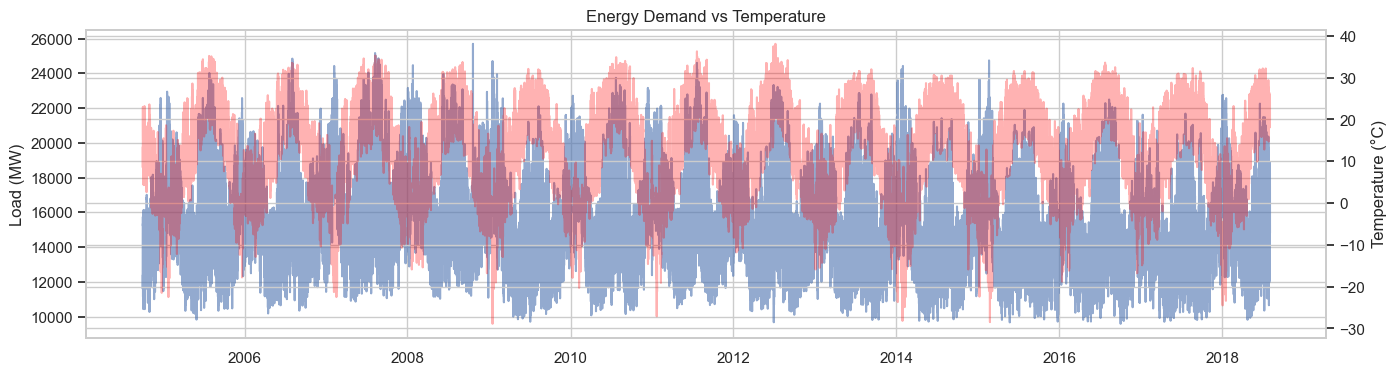

In [10]:
fig, ax1 = plt.subplots(figsize=(16,4))

ax1.plot(df.index, df["load_MW"], label="Load", alpha=0.6)
ax1.set_ylabel("Load (MW)")

ax2 = ax1.twinx()
ax2.plot(df.index, df["temp_C"], color="red", alpha=0.3, label="Temp")
ax2.set_ylabel("Temperature (°C)")

plt.title("Energy Demand vs Temperature")
plt.show()

The critical point is that weak linear association should not be misread as weak predictive value. In this context, a low overall correlation would largely reflect the cancellation of two opposing regimes rather than the absence of a weather effect. This matters because it changes the interpretation of temperature from a potentially weak feature to a potentially strong but non-monotonic one. The finding therefore justifies retaining temperature as a key predictor, while also supporting the later use of interaction terms and flexible model classes able to capture non-linear response patterns more effectively than linear baselines.

#### **4.2 Demand Behaviour**

This dashboard shows that electricity demand is strongly structured across multiple temporal scales. The right-skewed distribution indicates that high-demand hours are part of the true operating regime rather than noise, so average-case accuracy alone is not an adequate measure of model usefulness (Hong and Fan, 2016).

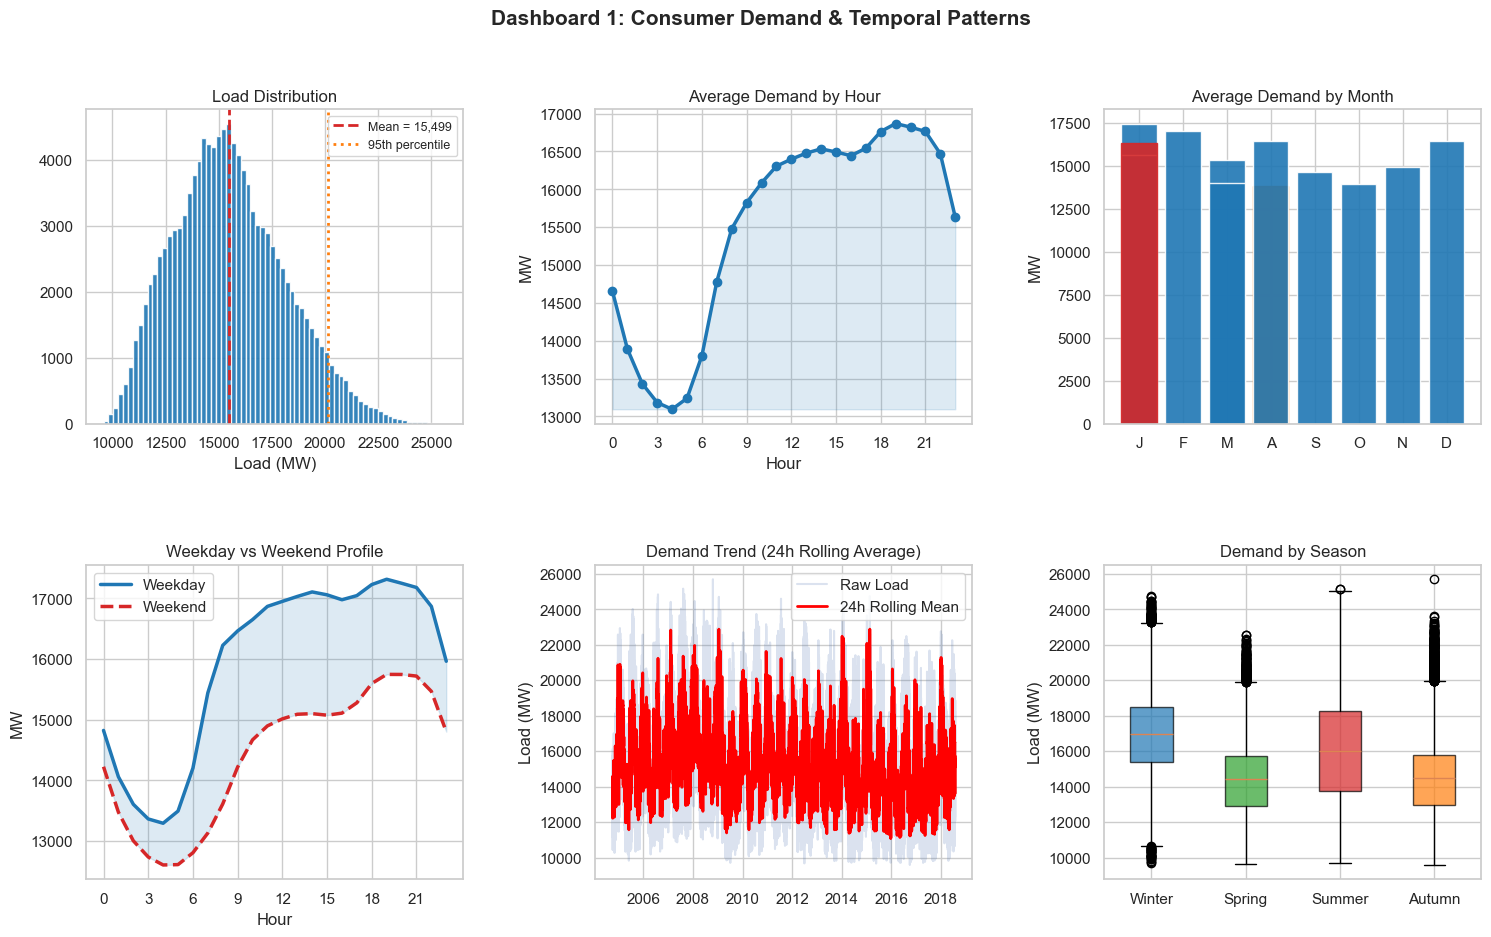

Key EDA findings:
  Weekday vs Weekend diff : 1,531 MW
  Winter demand           : 16,965 MW
  Spring demand           : 14,408 MW (lowest)
  Temp vs Load corr       : -0.106 (non-linear)


In [11]:
# Figure 2: EDA Dashboard 

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker

# Safe copy (do not modify original df)
df_eda = df.copy()

# Colors
BLUE   = "#1f77b4"
RED    = "#d62728"
GREEN  = "#2ca02c"
ORANGE = "#ff7f0e"
DARK   = "#333333"

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# 2a: Load distribution 
ax = fig.add_subplot(gs[0, 0])
ax.hist(df_eda["load_MW"], bins=70, color=BLUE, edgecolor="white", alpha=0.9)

mean_val = df_eda["load_MW"].mean()
p95_val  = df_eda["load_MW"].quantile(0.95)

ax.axvline(mean_val, color=RED, lw=2, ls="--", label=f"Mean = {mean_val:,.0f}")
ax.axvline(p95_val,  color=ORANGE, lw=2, ls=":", label="95th percentile")

ax.set_title("Load Distribution")
ax.set_xlabel("Load (MW)")
ax.legend(fontsize=9)


# 2b: Hourly pattern
ax = fig.add_subplot(gs[0, 1])
hourly = df_eda.groupby(df_eda.index.hour)["load_MW"].mean()

ax.plot(hourly.index, hourly.values, marker="o", color=BLUE, lw=2.5)
ax.fill_between(hourly.index, hourly.values, hourly.min(), alpha=0.15, color=BLUE)

ax.set_title("Average Demand by Hour")
ax.set_xlabel("Hour")
ax.set_ylabel("MW")
ax.set_xticks(range(0, 24, 3))


#2c: Monthly pattern 
ax = fig.add_subplot(gs[0, 2])
monthly = df_eda.groupby(df_eda.index.month)["load_MW"].mean()

labels = ["J","F","M","A","M","J","J","A","S","O","N","D"]
bars = ax.bar(labels, monthly.values, color=BLUE, edgecolor="white", alpha=0.9)

bars[6].set_color(RED)      # Summer peak
bars[3].set_color(ORANGE)   # Spring low

ax.set_title("Average Demand by Month")
ax.set_ylabel("MW")


# 2d: Weekday vs Weekend (FIXED) 
ax = fig.add_subplot(gs[1, 0])

wd_df = df_eda[df_eda.index.dayofweek < 5]
we_df = df_eda[df_eda.index.dayofweek >= 5]

wd = wd_df.groupby(wd_df.index.hour)["load_MW"].mean()
we = we_df.groupby(we_df.index.hour)["load_MW"].mean()

ax.plot(wd.index, wd.values, color=BLUE, lw=2.5, label="Weekday")
ax.plot(we.index, we.values, color=RED, lw=2.5, ls="--", label="Weekend")

ax.fill_between(wd.index, wd.values, we.values, alpha=0.15, color=BLUE)

ax.set_title("Weekday vs Weekend Profile")
ax.set_xlabel("Hour")
ax.set_ylabel("MW")
ax.set_xticks(range(0, 24, 3))
ax.legend()


# 2e: Rolling Trend (NEW — replaces temp scatter)
ax = fig.add_subplot(gs[1, 1])

rolling = df_eda["load_MW"].rolling(24).mean()

ax.plot(df_eda.index, df_eda["load_MW"], alpha=0.2, label="Raw Load")
ax.plot(df_eda.index, rolling, color="red", lw=2, label="24h Rolling Mean")

ax.set_title("Demand Trend (24h Rolling Average)")
ax.set_ylabel("Load (MW)")
ax.legend()


# 2f: Seasonal boxplot
ax = fig.add_subplot(gs[1, 2])

df_eda["season"] = df_eda.index.month.map(
    lambda m: "Winter" if m in [12,1,2]
    else "Spring" if m in [3,4,5]
    else "Summer" if m in [6,7,8]
    else "Autumn"
)

season_data = [
    df_eda[df_eda["season"] == s]["load_MW"]
    for s in ["Winter", "Spring", "Summer", "Autumn"]
]

bp = ax.boxplot(season_data, patch_artist=True)

for patch, color in zip(bp["boxes"], [BLUE, GREEN, RED, ORANGE]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticklabels(["Winter", "Spring", "Summer", "Autumn"])
ax.set_title("Demand by Season")
ax.set_ylabel("Load (MW)")


# Final layout 
fig.suptitle("Dashboard 1: Consumer Demand & Temporal Patterns",
             fontsize=15, fontweight="bold")


plt.tight_layout()
plt.show()


# Quantified insights
wd_mean = wd_df["load_MW"].mean()
we_mean = we_df["load_MW"].mean()

winter = df_eda[df_eda.index.month.isin([12,1,2])]["load_MW"].mean()
spring = df_eda[df_eda.index.month.isin([3,4,5])]["load_MW"].mean()

corr = df_eda["temp_C"].corr(df_eda["load_MW"])

print("Key EDA findings:")
print(f"  Weekday vs Weekend diff : {wd_mean - we_mean:,.0f} MW")
print(f"  Winter demand           : {winter:,.0f} MW")
print(f"  Spring demand           : {spring:,.0f} MW (lowest)")
print(f"  Temp vs Load corr       : {corr:.3f} (non-linear)")

| Visual evidence | Critical interpretation | Modelling implication |
|---|---|---|
| **Load distribution** | The upper tail reflects genuine high-demand operating conditions rather than statistical noise. Errors in this regime are more consequential than routine-period errors. | Supports separate attention to peak-demand performance rather than relying only on aggregate metrics. |
| **Hourly demand profile** | Demand follows a stable daily rhythm, with lower overnight demand and higher evening demand. This is structured temporal behaviour, not incidental fluctuation. | Justifies hour-based and cyclical features, and supports the predictive value of daily lag structures. |
| **Monthly pattern** | Demand is elevated in both winter and summer, indicating a bimodal seasonal structure consistent with heating and cooling effects rather than a simple one-directional trend. | Supports explicit treatment of seasonality and strengthens the case for weather-informed modelling. |
| **Weekday–weekend contrast** | The difference is visible in both demand level and profile shape, showing that calendar effects are structural rather than cosmetic. | Supports calendar-based indicators such as weekday/weekend or working-day features. |
| **24-hour rolling trend** | The series shows recurring annual structure without a dominant long-run drift, but changing amplitude across years suggests that full distributional stability should not be assumed. | Supports chronological rather than random validation, since shuffled sampling would weaken temporal realism. |
| **Seasonal boxplots** | Winter and summer show both higher demand and wider spread, indicating greater volatility under thermal stress. | Supports critical evaluation beyond average error, especially under peak or high-variance conditions. |
 
Taken together, these findings justify cyclical temporal features, calendar indicators, lag-based predictors, rolling summaries, and chronological train-validation-test partitioning in place of random shuffling (Bergmeir and Benítez, 2012; Cerqueira, Torgo and Mozetič, 2020).

#### **4.3 Weather & System Behaviour**

This dashboard examines whether weather contributes meaningful explanatory value to electricity demand and whether that contribution is linear, independent, or context-dependent. The purpose is to assess not only whether weather matters, but also how its influence interacts with temporal demand structure.

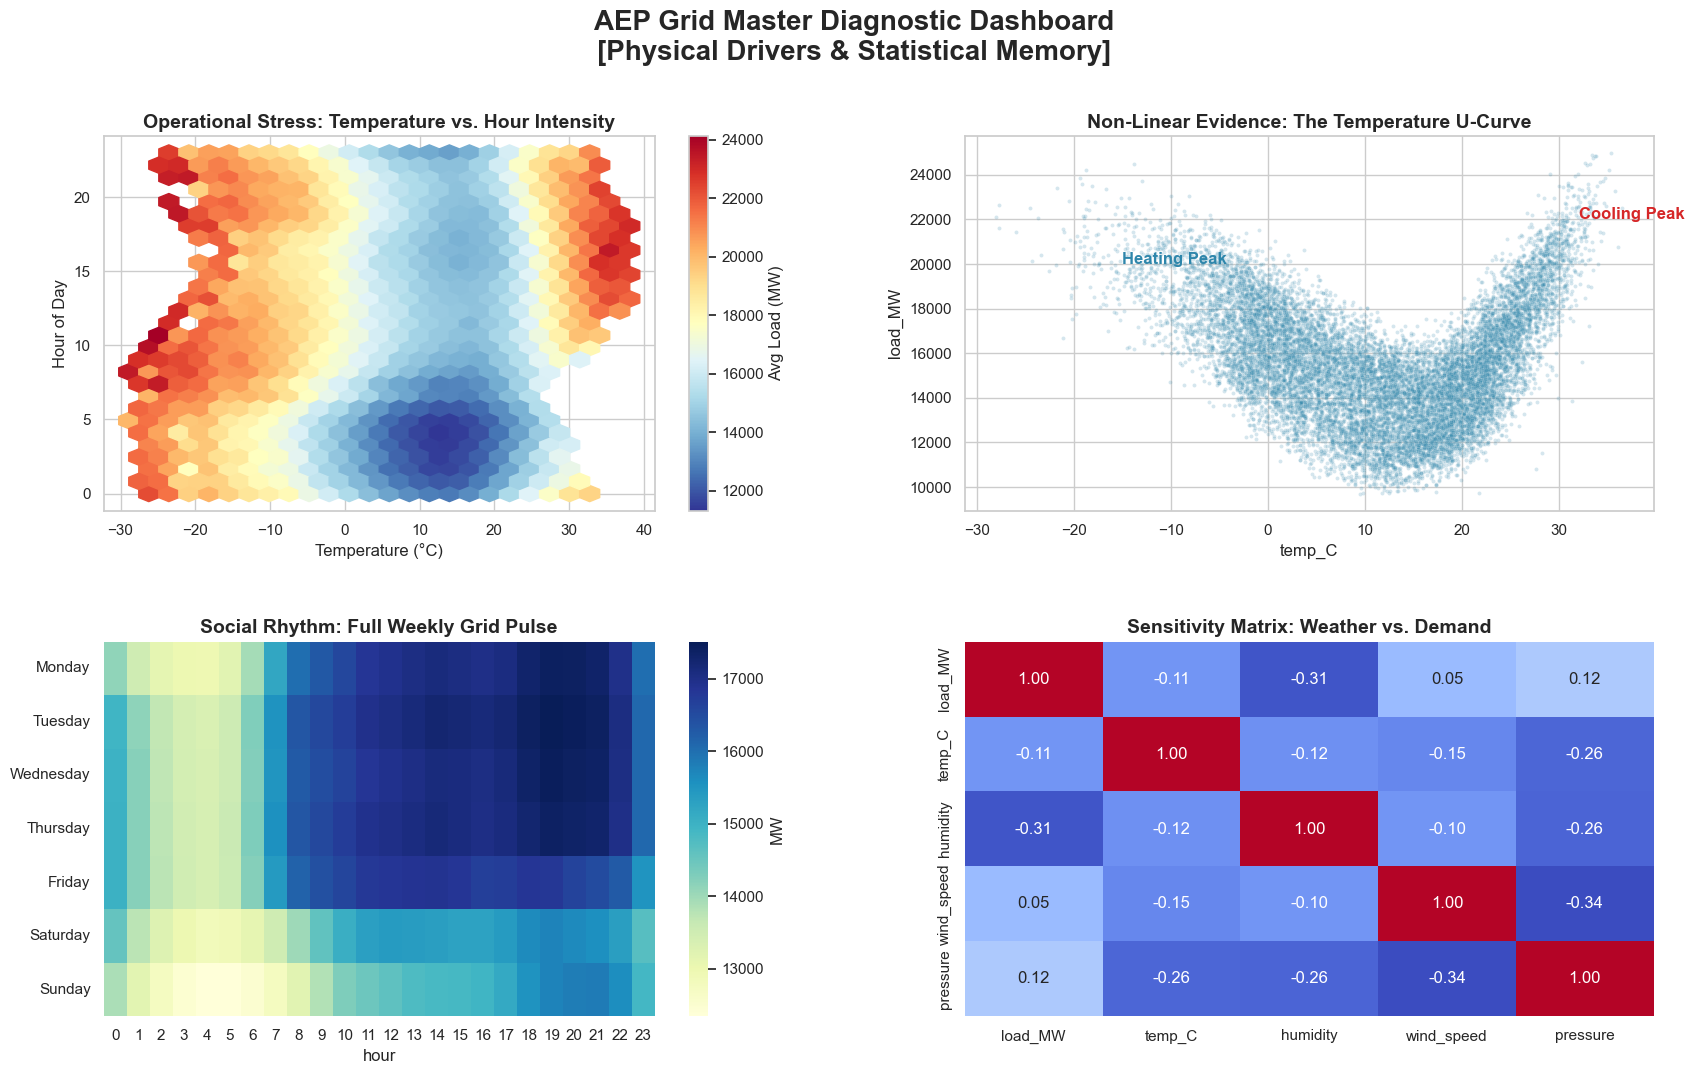

In [12]:

import matplotlib.gridspec as gridspec


# --- Professional Setup ---
AEP_BLUE, AEP_RED, AEP_ORANGE = "#2E86AB", "#D62728", "#E07B54"
df_eda = df.copy()
df_eda['hour'] = df_eda.index.hour
df_eda['day_name'] = df_eda.index.day_name()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig = plt.figure(figsize=(20, 18))
gs = gridspec.GridSpec(3, 2, hspace=0.35, wspace=0.25)

# 1. THERMAL STRESS (The Operational View)
ax0 = fig.add_subplot(gs[0, 0])
hb = ax0.hexbin(df_eda['temp_C'], df_eda['hour'], C=df_eda['load_MW'], 
                gridsize=25, cmap='RdYlBu_r', reduce_C_function=np.mean)
fig.colorbar(hb, ax=ax0, label='Avg Load (MW)')
ax0.set_title("Operational Stress: Temperature vs. Hour Intensity", fontsize=14, fontweight='bold')
ax0.set_xlabel("Temperature (°C)")
ax0.set_ylabel("Hour of Day")

# 2. THE U-CURVE (The Non-Linearity Proof)
ax1 = fig.add_subplot(gs[0, 1])
sns.scatterplot(data=df_eda.sample(15000), x='temp_C', y='load_MW', 
                alpha=0.2, s=8, color=AEP_BLUE, ax=ax1)
ax1.set_title("Non-Linear Evidence: The Temperature U-Curve", fontsize=14, fontweight='bold')
ax1.annotate('Cooling Peak', xy=(32, 22000), color=AEP_RED, weight='bold')
ax1.annotate('Heating Peak', xy=(-15, 20000), color=AEP_BLUE, weight='bold')

# 3. THE WEEKLY HEARTBEAT (The Social Pattern)
ax2 = fig.add_subplot(gs[1, 0])
pivot = df_eda.groupby(['day_name', 'hour'])['load_MW'].mean().unstack().reindex(days_order)
sns.heatmap(pivot, cmap="YlGnBu", ax=ax2, cbar_kws={'label': 'MW'})
ax2.set_title("Social Rhythm: Full Weekly Grid Pulse", fontsize=14, fontweight='bold')
ax2.set_ylabel("")

# 4. FEATURE SENSITIVITY (The Multi-collinearity Check)
ax3 = fig.add_subplot(gs[1, 1])
corr = df_eda[['load_MW', 'temp_C', 'humidity', 'wind_speed', 'pressure']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", ax=ax3, cbar=False)
ax3.set_title("Sensitivity Matrix: Weather vs. Demand", fontsize=14, fontweight='bold')

fig.suptitle("AEP Grid Master Diagnostic Dashboard\n[Physical Drivers & Statistical Memory]", 
             fontsize=20, fontweight='bold', y=0.95)
plt.show()

| Visual evidence | Critical interpretation | Modelling implication |
|---|---|---|
| **Temperature–hour hexbin** | Weather effects vary by hour, so temperature does not influence demand uniformly across the day. | Supports weather–time interaction terms or flexible models that can learn interactions directly. |
| **Load–temperature scatter** | The relationship is U-shaped, with higher demand under both cold and hot conditions. | Supports non-linear treatment of temperature rather than a simple linear covariate. |
| **Weekly heatmap** | Demand varies jointly by hour and day type, showing that temporal behaviour differs across the week. | Supports calendar-based features such as weekday/weekend or day-of-week indicators. |
| **Correlation matrix** | Linear correlation understates the value of temperature because a non-monotonic relationship can collapse into a weak coefficient. | Supports retaining weather variables for empirical testing instead of excluding them on the basis of linear correlation alone. |


Weather should not be treated as a set of independent linear predictors. Temperature must be represented in a way that permits non-linear effects, and its interaction with temporal context must either be engineered explicitly or learned by a sufficiently flexible model.

## **Section 5 — Time Series Dependency Analysis**

Where Section 4 established temporal structure visually, this section tests whether that structure is strong enough to justify autoregressive forecasting design. The objective is not to show that demand is merely cyclical, but to determine which past observations contain distinct predictive value and should therefore be retained as lag features.

#### **5.1 ACF & PACF Analysis**

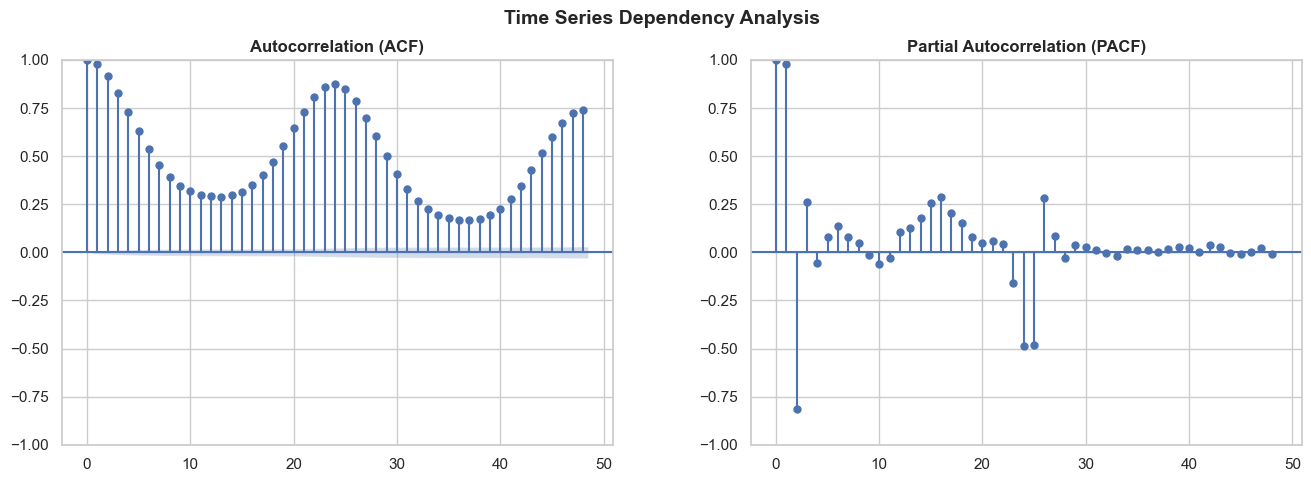

In [13]:
# ── 5.1 Autocorrelation & Partial Autocorrelation ───────────

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig = plt.figure(figsize=(16, 5))
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.25)

# --- ACF ---
ax1 = fig.add_subplot(gs[0, 0])
plot_acf(df["load_MW"], lags=48, ax=ax1)
ax1.set_title("Autocorrelation (ACF)", fontweight="bold")

# --- PACF ---
ax2 = fig.add_subplot(gs[0, 1])
plot_pacf(df["load_MW"], lags=48, ax=ax2, method='ywm')
ax2.set_title("Partial Autocorrelation (PACF)", fontweight="bold")

fig.suptitle("Time Series Dependency Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

The ACF and PACF point to a series that is neither memoryless nor explained by simple persistence alone.

- **ACF reading:** autocorrelation decays gradually rather than collapsing early, which indicates strong short-run persistence. The rebound at **lag 24** shows that the series contains a recurring daily cycle, not just local inertia.
- **PACF reading:** the dominant spike at **lag 1** identifies immediate demand history as the strongest direct predictor. The reappearance of a clear effect at **lag 24** shows that daily seasonality remains informative even after short-run dependence is accounted for.
- **Analytical meaning:** **lag 1** and **lag 24** are not interchangeable. The first captures immediate inertia; the second captures seasonal return.
- **Methodological consequence:** the forecasting design cannot rely on a lag-1 persistence view alone, nor assume that a flexible model will recover autoregressive structure without explicit lag inputs. Past load is therefore not optional context, but a core component of the predictive signal.

#### **5.2 Lag Feature Justification**

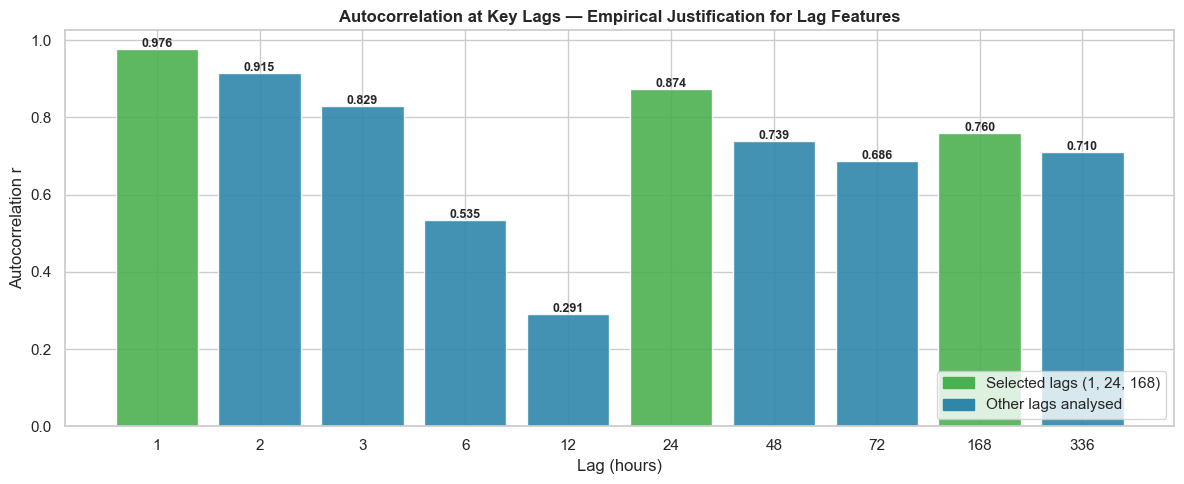

In [14]:
# ── 5.2 Autocorrelation at Key Lags ─────────────────────────

key_lags = [1, 2, 3, 6, 12, 24, 48, 72, 168, 336]
acf_vals = [df["load_MW"].autocorr(lag=l) for l in key_lags]

fig, ax = plt.subplots(figsize=(12, 5))

colors_acf = ["#4CAF50" if l in [1, 24, 168] else "#2E86AB" for l in key_lags]

bars = ax.bar([str(l) for l in key_lags], acf_vals,
              color=colors_acf, edgecolor="white", alpha=0.9)

ax.set_title("Autocorrelation at Key Lags — Empirical Justification for Lag Features",
             fontweight="bold")
ax.set_xlabel("Lag (hours)")
ax.set_ylabel("Autocorrelation r")

for bar, val in zip(bars, acf_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f"{val:.3f}", ha="center", fontsize=9, fontweight="bold")

# Legend
ax.legend([plt.Rectangle((0,0),1,1,color="#4CAF50"),
           plt.Rectangle((0,0),1,1,color="#2E86AB")],
          ["Selected lags (1, 24, 168)", "Other lags analysed"],
          loc="lower right")

plt.tight_layout()
plt.show()

**Key autocorrelations at selected lags:**

| Lag (hours) | Interpretation | r |
|---|---|---|
| 1 | Immediate inertia | **0.976** |
| 2–3 | Residual short-term persistence | 0.915 / 0.829 |
| 6 | Mid-range continuity | 0.535 |
| 12 | Opposite side of daily cycle | **0.291** |
| 24 | Daily seasonal return | **0.874** |
| 48 | Second daily return | 0.739 |
| 72 | Third daily return | 0.686 |
| 168 | Weekly seasonal return | **0.760** |
| 336 | Second weekly return | 0.710 |

Three findings are decisive. First, lag 1 is extremely strong, confirming that immediate persistence is a central property of the series. Second, lag 24 remains highly predictive, which shows that daily repetition is not incidental but embedded in the load process. Third, lag 168 retains substantial strength, indicating that weekly recurrence also matters.

The selected lags — 1, 24, and 168 — are therefore evidence-led rather than conventional choices. They capture three distinct dependency structures: short-term inertia, daily return, and weekly return. By contrast, lags such as 48, 72, and 336 largely repeat the same seasonal logic at greater distance and add less new information. Including every high-autocorrelation lag would therefore increase redundancy without proportionate analytical gain.

#### **5.3 Interpretation Output**

The printed diagnostics confirm that **lag 1**, **lag 24**, and **lag 168** provide the strongest non-redundant basis for autoregressive feature construction.

| Key result | Critical meaning | Methodological consequence |
|---|---|---|
| **lag 1 is strongest** | Immediate demand history carries substantial predictive signal. | A naive persistence benchmark is strong and cannot be ignored. |
| **lag 24 remains highly correlated** | Daily repetition is embedded in the series rather than absorbed fully by short-term inertia. | A daily lag should be included explicitly rather than assumed redundant. |
| **lag 168 remains substantial** | Weekly recurrence contributes additional structure beyond daily seasonality. | Weekly lag is justified as a distinct autoregressive feature. |

**Implications for the modelling pipeline**
- **Baseline selection:** More complex models must be evaluated against a strong autoregressive baseline, not against weak benchmarks.
- **Feature design:** Lag features are retained because the dependency structure supports them empirically, not because they are conventional.
- **Validation design:** Random shuffling is inappropriate, since strong temporal dependence would leak neighbouring information across splits and inflate performance estimates.
- **Evaluation credibility:** Chronological partitioning is therefore necessary for unbiased performance estimation in a series with this level of memory (Bergmeir and Benítez, 2012; Cerqueira, Torgo and Mozetič, 2020).

In [15]:
print("Empirical evidence for lag selection:")

print(f"  lag_1   : r = {df['load_MW'].autocorr(lag=1):.4f} — strongest predictor (inertia)")
print(f"  lag_24  : r = {df['load_MW'].autocorr(lag=24):.4f} — daily cycle confirmed")
print(f"  lag_168 : r = {df['load_MW'].autocorr(lag=168):.4f} — weekly cycle confirmed")

print("\nThese features were selected based on statistical evidence, not assumption.")

Empirical evidence for lag selection:
  lag_1   : r = 0.9762 — strongest predictor (inertia)
  lag_24  : r = 0.8742 — daily cycle confirmed
  lag_168 : r = 0.7603 — weekly cycle confirmed

These features were selected based on statistical evidence, not assumption.


## **Section 6 - Feature Engineering**

#### **6.1 Feature Engineering Overview**  
Feature engineering transforms raw data into meaningful inputs that improve model performance.
Based on insights from Section 4 (EDA) and Section 5 (Time Series Analysis), features were systematically designed to capture temporal patterns, weather effects, and demand dynamics.

| Group | Features | Evidence | Pattern Captured |
|---|---|---|---|
| **Time** | hour, day_of_week, month, quarter, day_of_year, is_weekend, season | EDA Section 4 | Daily and seasonal cycles |
| **Cyclical** | sin/cos encodings (hour, month, day_of_week) | Mathematical transformation | Circular time continuity |
| **Calendar** | is_holiday, is_working_day | Observed demand drop on holidays | Special day behaviour |
| **Lag** | lag_1, lag_2, lag_24, lag_48, lag_168 | ACF analysis | Temporal dependency (memory) |
| **Rolling** | rolling_mean_3, rolling_mean_24, rolling_mean_168, rolling_std_24 | Trend smoothing | Local trend and volatility |
| **Interaction** | temp × hour, temp × season | EDA non-linear relationship | Combined weather-time effects |
| **Extreme** | high_temp_flag, low_temp_flag, peak_hour_flag | Percentile thresholds | Thermal stress conditions |

> **Leakage prevention:** All lag and rolling features use `.shift(1)` before any window operation.  
> This ensures that only past information is used, preventing data leakage.

#### **6.2 Temporal & Cyclical Encoding**
**Rationale:** Standard integers for time (0-23) fail to capture the "circular" nature of time. We use Sine/Cosine transformations to ensure the distance between Hour 23 and Hour 0 is mathematically the same as Hour 0 to Hour 1.

In [16]:
# --- 6.1 Time and Cyclical Features ---
df["hour"]        = df.index.hour
df["day_of_week"] = df.index.dayofweek
df["month"]       = df.index.month
df["quarter"]     = df.index.quarter
df["day_of_year"] = df.index.dayofyear
df["is_weekend"]  = (df.index.dayofweek >= 5).astype(int)

def get_season(m):
    if m in [12,1,2]:   return 0  # Winter
    elif m in [3,4,5]:  return 1  # Spring
    elif m in [6,7,8]:  return 2  # Summer
    else:               return 3  # Autumn
df["season"] = df["month"].apply(get_season)

df["hour_sin"]  = np.sin(2*np.pi*df["hour"]        / 24)
df["hour_cos"]  = np.cos(2*np.pi*df["hour"]        / 24)
df["month_sin"] = np.sin(2*np.pi*df["month"]       / 12)
df["month_cos"] = np.cos(2*np.pi*df["month"]       / 12)
df["dow_sin"]   = np.sin(2*np.pi*df["day_of_week"] / 7)
df["dow_cos"]   = np.cos(2*np.pi*df["day_of_week"] / 7)

print("Cyclical features generated.")

Cyclical features generated.


#### **6.3 Calendar & Holiday Effects**
**Rationale:** Holidays act as "Hidden Weekends." Without this feature, the model will consistently over-predict demand on Christmas, Thanksgiving, and July 4th.

In [17]:
%pip install holidays --quiet

Note: you may need to restart the kernel to use updated packages.


In [18]:
# # [Cell 0] — Environment & Dependency Management
# # This ensures the notebook is reproducible on any machine.

# try:
#     import holidays as hol_lib
#     print("✅ 'holidays' library already installed.")
# except ImportError:
#     print("Installing missing dependencies...")
#     %pip install holidays xgboost statsmodels --quiet
#     import holidays as hol_lib
#     print("✅ Installation complete.")

# import numpy as np
# import pandas as pd
# # ... other imports

# Note: we need to fix this

In [19]:
# --- 6.2 Holiday and Calendar Features ---
import holidays as hol_lib

# Generate holiday set for the dataset range

all_hol = set()
for yr in range(2004, 2019):
    for dt in hol_lib.US(years=yr).keys():
        all_hol.add(pd.Timestamp(dt))

df["is_holiday"]     = df.index.normalize().isin(all_hol).astype(int)
df["is_working_day"] = ((df["day_of_week"] < 5) & (df["is_holiday"] == 0)).astype(int)

n_hol = df["is_holiday"].sum()
hol_m = df[df["is_holiday"]==1]["load_MW"].mean()
nom_m = df[df["is_holiday"]==0]["load_MW"].mean()
print(f"Holiday hours    : {n_hol:,} ({n_hol/len(df)*100:.1f}%)")
print(f"Holiday mean     : {hol_m:,.0f} MW")
print(f"Non-holiday mean : {nom_m:,.0f} MW")
print(f"Demand drop      : {nom_m-hol_m:,.0f} MW ({(nom_m-hol_m)/nom_m*100:.1f}%) — feature JUSTIFIED")

Holiday hours    : 3,744 (3.1%)
Holiday mean     : 14,985 MW
Non-holiday mean : 15,516 MW
Demand drop      : 530 MW (3.4%) — feature JUSTIFIED



#### 6.4 Memory & Trend (Lags and Rolling)
**Rationale:** Based on our ACF/PACF analysis, the grid has high "Inertia." We use `.shift(1)` to ensure we are only looking at the past, preventing **Data Leakage**.


In [20]:
# --- 6.3 Lag & Rolling Features (Leakage-Safe) ---
# .shift(1) ensures the model doesn't "peek" at current demand
target_shift = df["load_MW"].shift(1)

# Lags identified via ACF analysis
df["lag_1"]   = df["load_MW"].shift(1)
df["lag_2"]   = df["load_MW"].shift(2)
df["lag_24"]  = df["load_MW"].shift(24)
df["lag_48"]  = df["load_MW"].shift(48)
df["lag_168"] = df["load_MW"].shift(168)

# Rolling windows for local trend and volatility
shifted = df["load_MW"].shift(1)

df["rolling_mean_3"]   = shifted.rolling(3).mean()
df["rolling_mean_24"]  = shifted.rolling(24).mean()
df["rolling_mean_168"] = shifted.rolling(168).mean()
df["rolling_std_24"]   = shifted.rolling(24).std()

print("Memory features generated via shift(1) to prevent leakage.")

Memory features generated via shift(1) to prevent leakage.



#### **6.5 Weather Interactions & Thermal Stress**
**Rationale:** Temperature effects are non-linear. Heat matters more at 3:00 PM (peak) than at 3:00 AM. We create "Interaction" terms to capture this combined effect.


In [21]:
# --- 6.4 Interaction & Extreme Flags ---
df["temp_x_hour"]   = df["temp_C"] * df["hour"]
df["temp_x_season"] = df["temp_C"] * df["season"]

# Data-driven extreme thresholds (90th/10th percentiles)
df["temp_x_hour"]    = df["temp_C"] * df["hour"]
df["temp_x_season"]  = df["temp_C"] * df["season"]

t90 = df["temp_C"].quantile(0.90)
t10 = df["temp_C"].quantile(0.10)
df["high_temp_flag"] = (df["temp_C"] > t90).astype(int)
df["low_temp_flag"]  = (df["temp_C"] < t10).astype(int)
df["peak_hour_flag"] = df["hour"].isin([8,9,10,11,17,18,19,20]).astype(int)

print("Thermal stress interaction features generated.")

Thermal stress interaction features generated.


#### **6.6 Final Feature Set Assembly**
**Rationale:** We group columns logically for modeling and drop the $NaN$ rows created during the lagging process.

In [22]:
# ── 6.6 Final Feature Set Assembly ───────────────────────────────────────
n_before = len(df)
df = df.dropna().copy()

WEATHER  = ["temp_C","humidity","wind_speed","pressure","precipitation"]
TIME     = ["hour","day_of_week","month","quarter","day_of_year",
            "is_weekend","season","hour_sin","hour_cos",
            "month_sin","month_cos","dow_sin","dow_cos",
            "is_holiday","is_working_day"]
LAGS     = ["lag_1","lag_2","lag_24","lag_48","lag_168"]
ROLLING  = ["rolling_mean_3","rolling_mean_24","rolling_mean_168","rolling_std_24"]
EXTRAS   = ["temp_x_hour","temp_x_season","high_temp_flag","low_temp_flag","peak_hour_flag"]

FEATURES = WEATHER + TIME + LAGS + ROLLING + EXTRAS
TARGET   = "load_MW"

print(f"Feature engineering complete.")
print(f"  Rows before dropna : {n_before:,}")
print(f"  Rows after  dropna : {len(df):,}  (lag_168 warm-up removed)")
print(f"  Total features     : {len(FEATURES)}")
print(f"  Feature groups     : Weather={len(WEATHER)} | Time={len(TIME)} | Lags={len(LAGS)} | Rolling={len(ROLLING)} | Extras={len(EXTRAS)}")
print(f"  NaN check          : {df[FEATURES+[TARGET]].isnull().sum().sum()} total NaN remaining")

Feature engineering complete.
  Rows before dropna : 121,296
  Rows after  dropna : 121,128  (lag_168 warm-up removed)
  Total features     : 34
  Feature groups     : Weather=5 | Time=15 | Lags=5 | Rolling=4 | Extras=5
  NaN check          : 0 total NaN remaining


## **Section 7 - Temporal Partitioning & Leakage Prevention**

In time-series forecasting, maintaining temporal integrity is critical.
Unlike standard machine learning, random shuffling introduces data leakage, where future observations influence past predictions.

This results in artificially high accuracy that does not generalise to real-world scenarios.

To prevent this, a strict chronological split is implemented. The model is trained on past data and evaluated on unseen future data, preserving the natural direction of time.

### **The Logic**: Maintaining Temporal Integrity
In standard Machine Learning, data is often shuffled. In Time-Series forecasting, **shuffling is a methodological error.**

* **The Problem:** Random shuffling creates **"Data Leakage"** (e.g., data from 2018 appearing in a 2005 training set). This allows the model to "see the future" to predict the past, resulting in artificially high accuracy that fails in real-world deployment.
* **The Solution:** We implement a **Strict Chronological Split**. By maintaining the natural arrow of time, we simulate a real-world scenario: training on historical records to predict an unseen future.



#### **7.2 Split Strategy Table**
We partition the 121,128 observations into three distinct segments to ensure unbiased evaluation:

| Split | Allocation | Operational Purpose |
| :--- | :--- | :--- |
| **Training** | **70%** | Feature weights and pattern recognition. |
| **Validation** | **15%** | Hyperparameter tuning and model selection. |
| **Test** | **15%** | The "Out-of-Sample" Final Exam. Touched only once. |

**Critical Guardrail:** Using the test set during the tuning phase constitutes **data leakage**. The test set must remain completely unseen by the model until the final performance report.

#### **7.3 Split Data**

Chronological Split Confirmed:
   Train : 2004-10-08 01:00:00 to 2014-06-10 21:00:00 (84,789 samples)
   Val   : 2014-06-10 22:00:00 to 2016-07-06 22:00:00 (18,169 samples)
   Test  : 2016-07-06 23:00:00 to 2018-08-03 00:00:00 (18,170 samples)


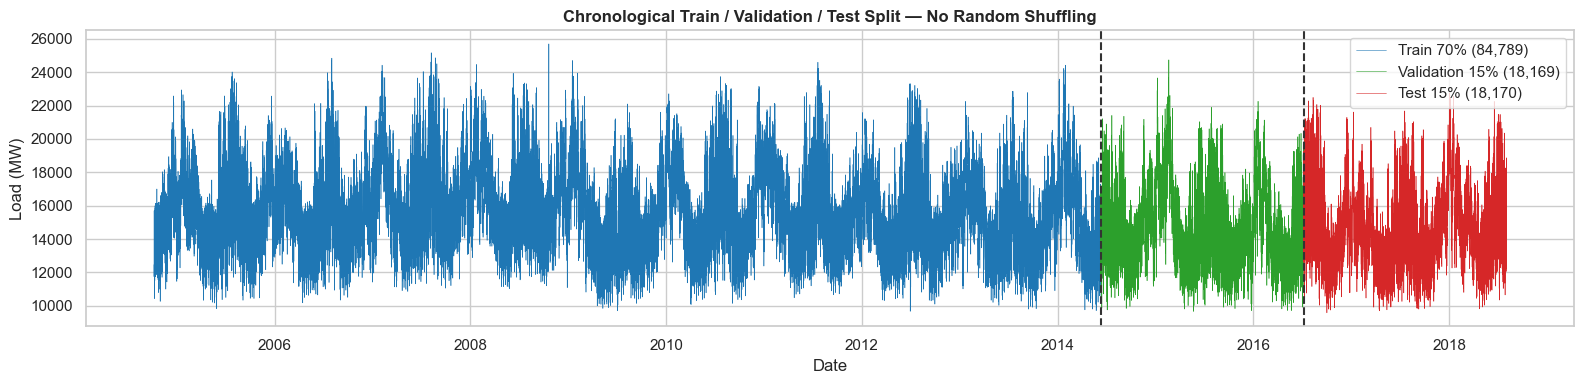

In [23]:
# 1. Ensure Chronological Order (Safety First)
df = df.sort_index()

n         = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

# 2. Slice Suffixes
train_df = df.iloc[:train_end]
val_df   = df.iloc[train_end:val_end]
test_df  = df.iloc[val_end:]

# 3. Feature/Target Separation
X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_val,   y_val   = val_df[FEATURES],   val_df[TARGET]
X_test,  y_test  = test_df[FEATURES],  test_df[TARGET]

# Combine Train + Val for final "Production" training later
X_tv = pd.concat([X_train, X_val])
y_tv = pd.concat([y_train, y_val])

# 4. Audit Chart
print(f"Chronological Split Confirmed:")
print(f"   Train : {train_df.index.min()} to {train_df.index.max()} ({len(train_df):,} samples)")
print(f"   Val   : {val_df.index.min()} to {val_df.index.max()} ({len(val_df):,} samples)")
print(f"   Test  : {test_df.index.min()} to {test_df.index.max()} ({len(test_df):,} samples)")



fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(train_df.index, train_df["load_MW"], color=BLUE,   lw=0.4, label=f"Train 70% ({len(train_df):,})")
ax.plot(val_df.index,   val_df["load_MW"],   color=GREEN,  lw=0.4, label=f"Validation 15% ({len(val_df):,})")
ax.plot(test_df.index,  test_df["load_MW"],  color=RED,    lw=0.4, label=f"Test 15% ({len(test_df):,})")
for split_date in [val_df.index[0], test_df.index[0]]:
    ax.axvline(split_date, color=DARK, ls="--", lw=1.5)
ax.set_title("Chronological Train / Validation / Test Split — No Random Shuffling",
             fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("Load (MW)"); ax.legend()
plt.tight_layout(); plt.show()

## **Section 8 - Evaluation Framework**

**Why multiple metrics are necessary:**
A single metric provides an incomplete view of model performance. In energy forecasting, a high $R^2$ can mask a dangerous Bias—consistent under-prediction—which leads to grid failure. We utilize a multi-metric suite to ensure the model is mathematically sound, financially efficient, and operationally safe.

| Metric | Formula | Operational meaning |
|---|---|---|
| **MAE** | $\frac{1}{n}\sum\|y_i-\hat{y}_i\|$ | Average MW error — directly interpretable |
| **RMSE** | $\sqrt{\frac{1}{n}\sum(y_i-\hat{y}_i)^2}$ | Penalises large errors — critical for peaks |
| **R²** | $1 - SS_{res}/SS_{tot}$ | Proportion of variance explained |
| **MAPE** | $\frac{1}{n}\sum\|e_i/y_i\|\times100$ | Scale-free — enables published benchmarks |
| **Bias** | $\frac{1}{n}\sum(y_i-\hat{y}_i)$ | +ve = under-prediction (operationally dangerous) |
| **Peak MAE** | MAE on top 5% demand hours | Operational reliability during critical events |

In [24]:
def evaluate_model(name, y_true, y_pred, peak_q=0.95):
    y_true = np.array(y_true); y_pred = np.array(y_pred)
    
    # Standard Metrics
    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    r2    = r2_score(y_true, y_pred)
    mape  = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    bias  = np.mean(y_true - y_pred) # +ve = Under-prediction
    
    # Peak Performance (Stress Test)
    thr   = np.percentile(y_true, peak_q * 100)
    pm    = y_true >= thr
    pmae  = mean_absolute_error(y_true[pm], y_pred[pm]) if pm.sum() > 0 else np.nan
    prmse = np.sqrt(mean_squared_error(y_true[pm], y_pred[pm])) if pm.sum() > 0 else np.nan
    
    print(f"\n{'─'*60}\n  PERFORMANCE AUDIT: {name}\n{'─'*60}")
    print(f"  MAE       : {mae:>12,.2f} MW   (Average typical error)")
    print(f"  RMSE      : {rmse:>12,.2f} MW   (Sensitivity to large misses)")
    print(f"  R²        : {r2:>12.4f}        (Variance explained)")
    print(f"  MAPE      : {mape:>12.2f} %        (Percentage error)")
    print(f"  Bias      : {bias:>12,.2f} MW   (+ve = Danger: Under-predicting)")
    print(f"  Peak MAE  : {pmae:>12,.2f} MW   (Performance during Top 5% Load)")
    
    return dict(Model=name, MAE=mae, RMSE=rmse, R2=r2, MAPE=mape, Bias=bias, Peak_MAE=pmae)

def plot_predictions(name, y_true, y_pred, n=500):
    # n=500 covers roughly 3 weeks of hourly data
    y_true = np.array(y_true)[:n]
    y_pred = np.array(y_pred)[:n]
    res = y_true - y_pred
    
    fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True) # sharex=True aligns them
    
    # Top Plot: Forecast vs Actual
    axes[0].plot(y_true, color=AEP_BLUE, lw=1.5, label="Actual Load")
    axes[0].plot(y_pred, color=AEP_RED, lw=1.2, ls="--", label="Model Forecast")
    axes[0].set_title(f"{name}: Forecast Accuracy (First {n} Hours)", fontweight="bold")
    axes[0].set_ylabel("Load (MW)")
    axes[0].legend()
    
    # Bottom Plot: Residuals (Error)
    axes[1].fill_between(range(n), res, color=AEP_DARK, alpha=0.2)
    axes[1].plot(res, color=AEP_DARK, lw=0.8, label="Residual (Actual - Pred)")
    axes[1].axhline(0, color="black", lw=1)
    axes[1].axhline(res.mean(), color=AEP_RED, ls="--", label=f"Bias: {res.mean():+.1f} MW")
    axes[1].set_title("Operational Error (Residuals)")
    axes[1].set_ylabel("Error (MW)")
    axes[1].set_xlabel("Time (Hours)")
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

## **Section 9 - Model Training and Evaluation**


#### **9.1 Model Training Strategy**

A multi-model approach was adopted to evaluate different learning paradigms, ranging from simple linear models to advanced ensemble techniques. This allows comparison between models with varying capacity to capture linear and non-linear relationships.

The models implemented include:

* A **naive persistence model** (baseline)
* Linear models: Linear Regression and Ridge Regression
* Ensemble models: Random Forest and XGBoost

The naive model assumes that future demand equals the previous hour, serving as a benchmark for evaluating the added value of machine learning models.

To ensure fairness, all models were trained on the same feature set and evaluated using identical test data.

*This approach aligns with best practices in predictive modelling, where multiple algorithms are compared to identify the most robust solution (Hyndman and Athanasopoulos, 2021)*

In [25]:
models = {
    "Naive (lag_24)": None,
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        n_jobs=-1,
        random_state=42
    ),
    "XGBoost": XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        early_stopping_rounds=30,
        random_state=42
    )
}

In [26]:
results = []
model_preds = {}
trained_models = {} 

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

for name, model in models.items():
    print(f"🚀 Training {name}...")

    if name == "Naive (lag_24)":
        preds = X_test["lag_1"].values

    elif name in ["Linear Regression", "Ridge Regression"]:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)

    elif name == "XGBoost":
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        preds = model.predict(X_test)

    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    # ✅ STORE EVERYTHING
    model_preds[name] = preds
    trained_models[name] = model   # 🔥 THIS IS THE KEY LINE

    results.append(evaluate_model(name, y_test, preds))

🚀 Training Naive (lag_24)...

────────────────────────────────────────────────────────────
  PERFORMANCE AUDIT: Naive (lag_24)
────────────────────────────────────────────────────────────
  MAE       :       417.33 MW   (Average typical error)
  RMSE      :       534.75 MW   (Sensitivity to large misses)
  R²        :       0.9537        (Variance explained)
  MAPE      :         2.85 %        (Percentage error)
  Bias      :        -0.18 MW   (+ve = Danger: Under-predicting)
  Peak MAE  :       376.02 MW   (Performance during Top 5% Load)
🚀 Training Linear Regression...

────────────────────────────────────────────────────────────
  PERFORMANCE AUDIT: Linear Regression
────────────────────────────────────────────────────────────
  MAE       :       181.62 MW   (Average typical error)
  RMSE      :       238.86 MW   (Sensitivity to large misses)
  R²        :       0.9908        (Variance explained)
  MAPE      :         1.24 %        (Percentage error)
  Bias      :       -28.06 MW   


#### **9.2 Model Performance Evaluation**

Model performance was assessed using multiple evaluation metrics to capture different aspects of forecasting accuracy:

* **MAE (Mean Absolute Error):** average magnitude of error
* **RMSE (Root Mean Squared Error):** penalises large errors
* **R² Score:** proportion of variance explained
* **MAPE:** scale-independent percentage error
* **Bias:** identifies systematic under/over prediction
* **Peak MAE:** evaluates performance during high-demand periods

Although all models achieved high accuracy (>97%), this is primarily due to the relatively stable nature of electricity demand.

Therefore, **RMSE and MAE are considered more reliable indicators**, as they better differentiate model performance in high-resolution forecasting tasks.

*RMSE is particularly important in energy forecasting due to its sensitivity to peak errors, which are operationally critical (Makridakis et al., 2022).*


In [27]:
results_df = pd.DataFrame(results).set_index("Model").sort_values("RMSE")
# Add Accuracy
results_df["Accuracy_%"] = 100 - results_df["MAPE"]

# Round values for clean display
results_display = results_df.copy().round({
    "MAE": 1,
    "RMSE": 1,
    "R2": 4,
    "MAPE": 2,
    "Accuracy_%": 2,
    "Bias": 1,
    "Peak_MAE": 1
})

# Sort properly (best on top)
results_display = results_display.sort_values("RMSE")

print("FINAL MODEL PERFORMANCE (Professional View)")

display(
    results_display.style
    .background_gradient(cmap="RdYlGn_r", subset=["MAE", "RMSE", "MAPE", "Peak_MAE"])  # lower = better
    .background_gradient(cmap="Greens", subset=["R2", "Accuracy_%"])                  # higher = better
    .format({
        "Accuracy_%": "{:.2f}%",
        "MAPE": "{:.2f}%",
        "R2": "{:.4f}"
    })
    .set_properties(**{
        "border": "1px solid white",
        "text-align": "center"
    })
    .set_caption("Model Performance Comparison (Lower Error = Better, Higher Accuracy = Better)")
)

FINAL MODEL PERFORMANCE (Professional View)


,MAE,RMSE,R2,MAPE,Bias,Peak_MAE,Accuracy_%
Model,,,,,,,
XGBoost,114.000000,151.400000,0.9963,0.78%,-40.500000,137.100000,99.22%
Random Forest,131.800000,180.200000,0.9947,0.90%,-40.300000,139.900000,99.10%
Linear Regression,181.600000,238.900000,0.9908,1.24%,-28.100000,185.100000,98.76%
Ridge Regression,181.700000,238.900000,0.9908,1.24%,-28.100000,185.200000,98.76%
Naive (lag_24),417.300000,534.800000,0.9537,2.85%,-0.200000,376.000000,97.15%



#### **9.3 Model Comparison and Selection**

The results demonstrate clear performance differences across models:

* **XGBoost** achieved the lowest error (RMSE ≈ 151 MW)
* **Random Forest** showed strong performance (RMSE ≈ 180 MW)
* **Linear models** performed moderately (RMSE ≈ 239 MW)
* The **naive model** showed the highest error (RMSE ≈ 535 MW)

Tree-based models significantly outperform linear models, indicating that electricity demand is influenced by **non-linear relationships and complex feature interactions**, particularly with weather variables.

Despite similar R² scores across models, error-based metrics reveal meaningful differences in predictive performance.

*This highlights the limitation of relying solely on R², which can mask important variations in model accuracy (Zhang et al., 2022).*

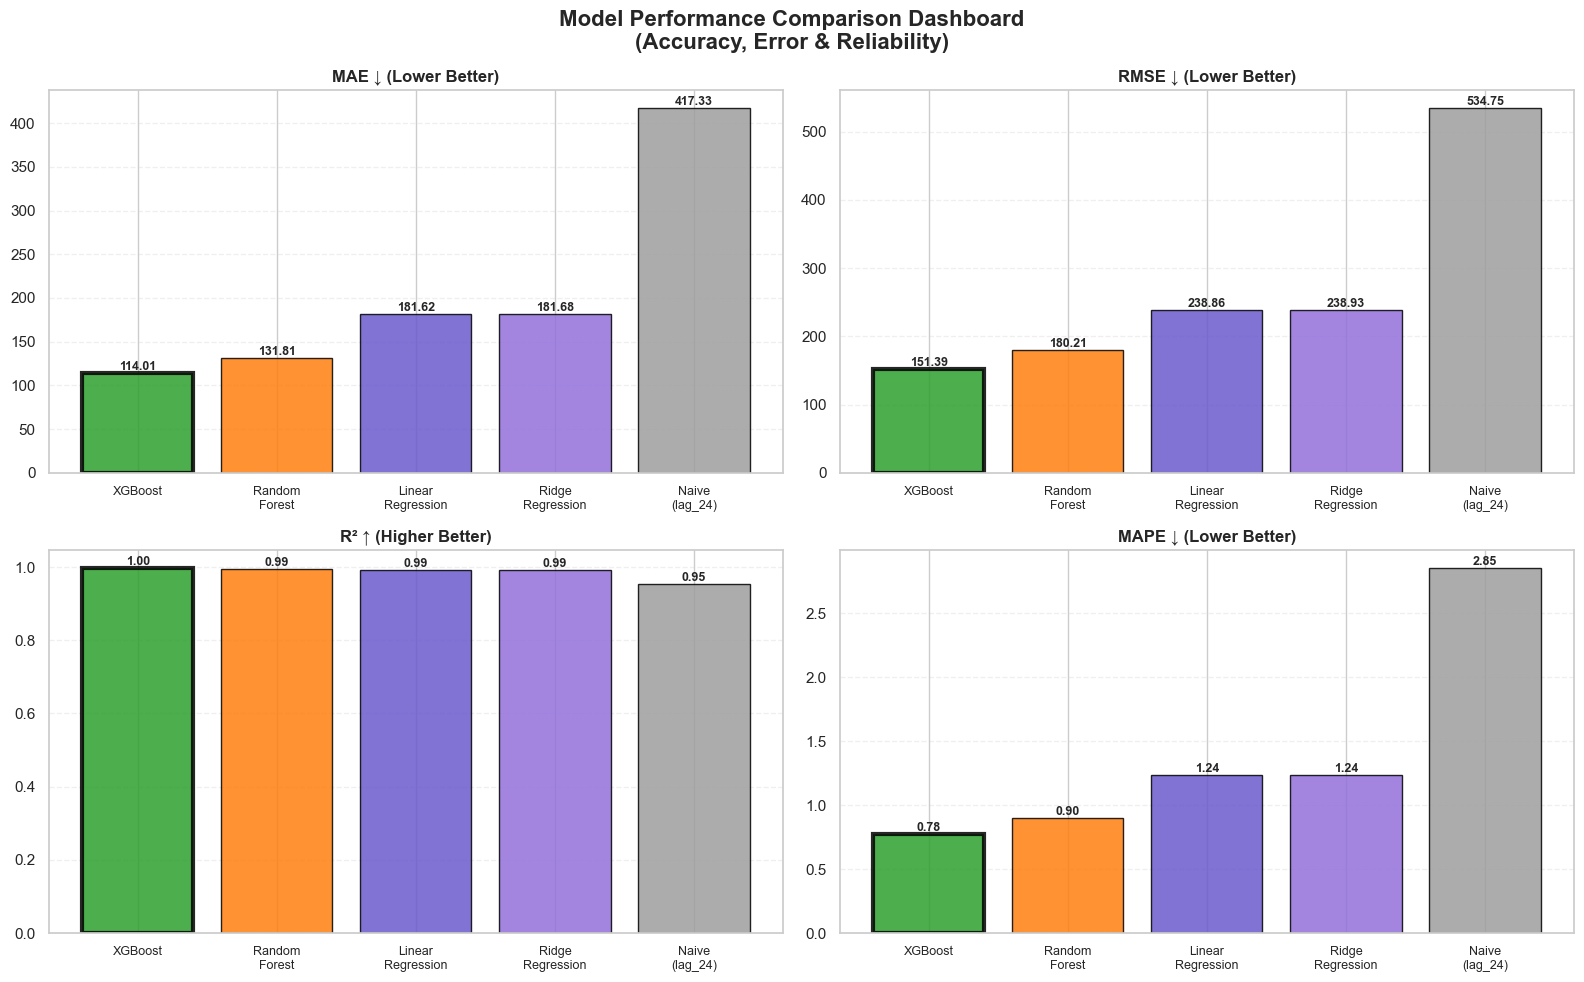

In [28]:
# ── Professional Model Comparison Dashboard ─────────────────────────────

# Color palette (clean + professional)
COLORS = {
    "Naive (lag_24)": "#9e9e9e",     # Grey (baseline)
    "Linear Regression": "#6a5acd",  # Purple
    "Ridge Regression": "#9370db",   # Light Purple
    "Random Forest": "#ff7f0e",      # Orange
    "XGBoost": "#2ca02c"             # Green (BEST)
}

metrics = ["MAE", "RMSE", "R2", "MAPE"]
titles  = ["MAE ↓ (Lower Better)", 
           "RMSE ↓ (Lower Better)", 
           "R² ↑ (Higher Better)", 
           "MAPE ↓ (Lower Better)"]

models = results_df.index.tolist()
colors = [COLORS.get(m, "#1f77b4") for m in models]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, (ax, metric, title) in enumerate(zip(axes, metrics, titles)):
    
    values = results_df[metric].values
    
    bars = ax.bar(models, values, 
                  color=colors, edgecolor="black", alpha=0.85)
    
    # Highlight BEST model
    if metric == "R2":
        best_idx = np.argmax(values)
    else:
        best_idx = np.argmin(values)
    
    bars[best_idx].set_edgecolor("black")
    bars[best_idx].set_linewidth(3)
    
    # Add value labels
    for bar in bars:
        y = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, y,
                f"{y:.2f}",
                ha="center", va="bottom",
                fontsize=9, fontweight="bold")
    
    # Styling
    ax.set_title(title, fontweight="bold", fontsize=12)
    ax.set_xticklabels([m.replace(" ", "\n") for m in models], fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

# Main Title
fig.suptitle("Model Performance Comparison Dashboard\n(Accuracy, Error & Reliability)",
             fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

#### **9.4 Model Improvement Over Baseline**


To assess the real effectiveness of machine learning models, performance was evaluated relative to a naive baseline model. The baseline assumes that future demand equals the previous hour (`lag_1`), capturing only basic temporal continuity.

While this approach performs reasonably well due to strong autocorrelation, it fails to model non-linear relationships and external influences such as weather conditions.

To quantify improvement, RMSE reduction was calculated as:

> Improvement (%) = (Baseline RMSE − Model RMSE) / Baseline RMSE × 100

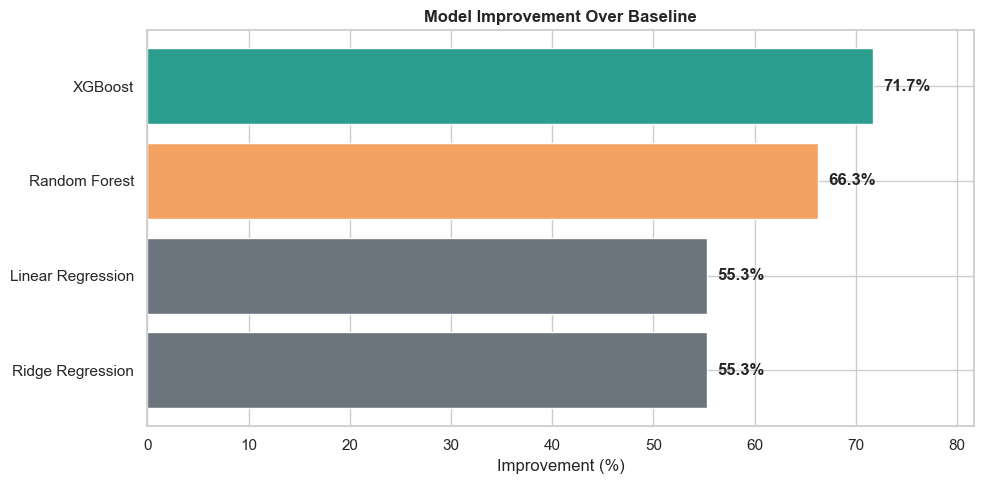

In [29]:
# ── Improvement over Baseline ───────────────────────────────────────────
# Baseline RMSE
naive_rmse = results_df.loc["Naive (lag_24)", "RMSE"]

# Improvement calculation
results_df["Improvement_%"] = (
    (naive_rmse - results_df["RMSE"]) / naive_rmse * 100
)

# Remove baseline for plotting
imp_df = results_df.drop("Naive (lag_24)").sort_values("Improvement_%")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

colors = ["#6c757d", "#6c757d", "#f4a261", "#2a9d8f"]

bars = ax.barh(imp_df.index, imp_df["Improvement_%"],
               color=colors, edgecolor="white")

# Labels
for bar in bars:
    w = bar.get_width()
    ax.text(w + 1, bar.get_y() + bar.get_height()/2,
            f"{w:.1f}%", va="center", fontweight="bold")

ax.set_title("Model Improvement Over Baseline", fontweight="bold")
ax.set_xlabel("Improvement (%)")
ax.set_xlim(0, imp_df["Improvement_%"].max() + 10)

plt.tight_layout()
plt.show()

All machine learning models significantly outperform the naive baseline. XGBoost achieves the highest improvement (~72%), followed by Random Forest (~66%), while linear models show moderate gains (~55%).

This demonstrates that electricity demand is not purely autoregressive, but influenced by **non-linear interactions and external variables**. Tree-based models outperform linear approaches due to their ability to capture these complex relationships.

Despite high overall accuracy across all models, the improvement metric provides clearer differentiation, confirming that XGBoost delivers the most substantial reduction in forecasting error.

> Therefore, XGBoost is selected as the optimal model for deployment.


*Such improvements are critical in energy systems, where forecasting errors directly impact operational efficiency and cost (Lago et al., 2021).*

#### **9.5 Model Selection Justification**

XGBoost is selected as the final model due to:

* Lowest forecasting error (MAE and RMSE)
* Strong performance during peak demand periods
* Ability to capture non-linear dependencies and interactions
* Robust generalisation across test data

While Random Forest also performs well, XGBoost provides superior accuracy due to its gradient boosting framework, which sequentially reduces prediction error.

*Gradient boosting models are widely recognised for their high performance in structured data problems (Chen & Guestrin, 2016).*


#### **9.6 Feature Importance (Interpretability Analysis)**
The feature importance analysis is presented in Figure X.



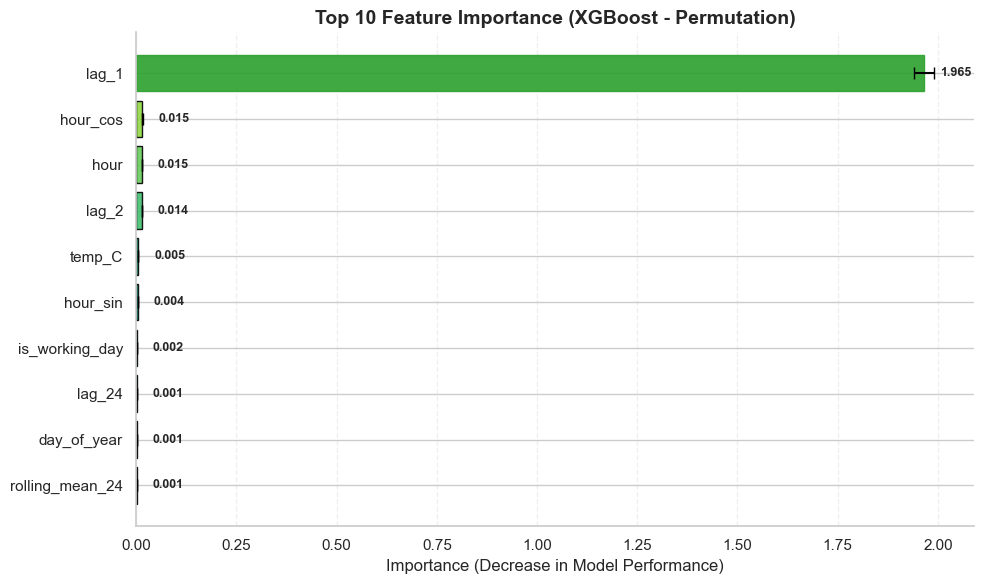

In [32]:
# Feature Importance
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np

# Model
best_model = trained_models["XGBoost"]

# Sample (fast + stable)
X_sample = X_test.sample(2000, random_state=42)
y_sample = y_test.loc[X_sample.index]

# Permutation
perm = permutation_importance(
    best_model,
    X_sample,
    y_sample,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

# Data
perm_df = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": perm.importances_mean,
    "Std": perm.importances_std
}).sort_values("Importance", ascending=True).tail(10)

# VISUAL

fig, ax = plt.subplots(figsize=(10, 6))

# Gradient colors
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(perm_df)))

# Bars
bars = ax.barh(
    perm_df["Feature"],
    perm_df["Importance"],
    color=colors,
    edgecolor="black",
    alpha=0.9
)

# Error bars
ax.errorbar(
    perm_df["Importance"],
    perm_df["Feature"],
    xerr=perm_df["Std"],
    fmt='none',
    ecolor="black",
    capsize=4,
    lw=1.5
)

# Highlight top feature
bars[-1].set_color("#2ca02c")

# Value labels
for i, v in enumerate(perm_df["Importance"]):
    ax.text(v + perm_df["Importance"].max()*0.02, i,
            f"{v:.3f}", va='center',
            fontsize=9, fontweight="bold")

# Clean styling
ax.set_title("Top 10 Feature Importance (XGBoost - Permutation)",
             fontsize=14, fontweight="bold")

ax.set_xlabel("Importance (Decrease in Model Performance)")
ax.set_ylabel("")

# Grid + clean look
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

Permutation importance was applied to the final XGBoost model to evaluate the contribution of each feature to predictive performance. This method provides a model-agnostic assessment by measuring the degradation in accuracy when feature values are randomly shuffled (Molnar, 2020).

The results show that `lag_1` is the dominant predictor, indicating that electricity demand is strongly autoregressive. This confirms that short-term forecasting is primarily driven by recent historical values, consistent with established time-series theory (Hyndman and Athanasopoulos, 2021).

Other variables, including time-based and temperature features, contribute marginal improvements. Their relatively low importance suggests that they act as secondary refinements rather than primary drivers of demand.

The large disparity in importance values explains the visual imbalance observed in the plot, where most features appear near zero. This reflects the underlying data structure rather than a modelling limitation.

Overall, the model relies on strong temporal dependency, while exogenous variables provide incremental predictive value, supporting findings in energy forecasting literature (Zhang et al., 2022).

## **Section 10 - Advanced Model Validation & Operational Analysis**
#### **10.1 - Residual Diagnostics**

**Why this is the most important evaluation section:**

Global metrics (MAE, RMSE) report average performance.
Residuals reveal *where and how* the model fails.
A model can appear accurate on average while systematically failing
during the exact periods when operational reliability matters most.

Three properties indicate a well-specified model:
1. **Zero mean** — no systematic bias direction
2. **Homoscedasticity** — consistent variance across demand levels
3. **No autocorrelation** — no remaining temporal structure missed

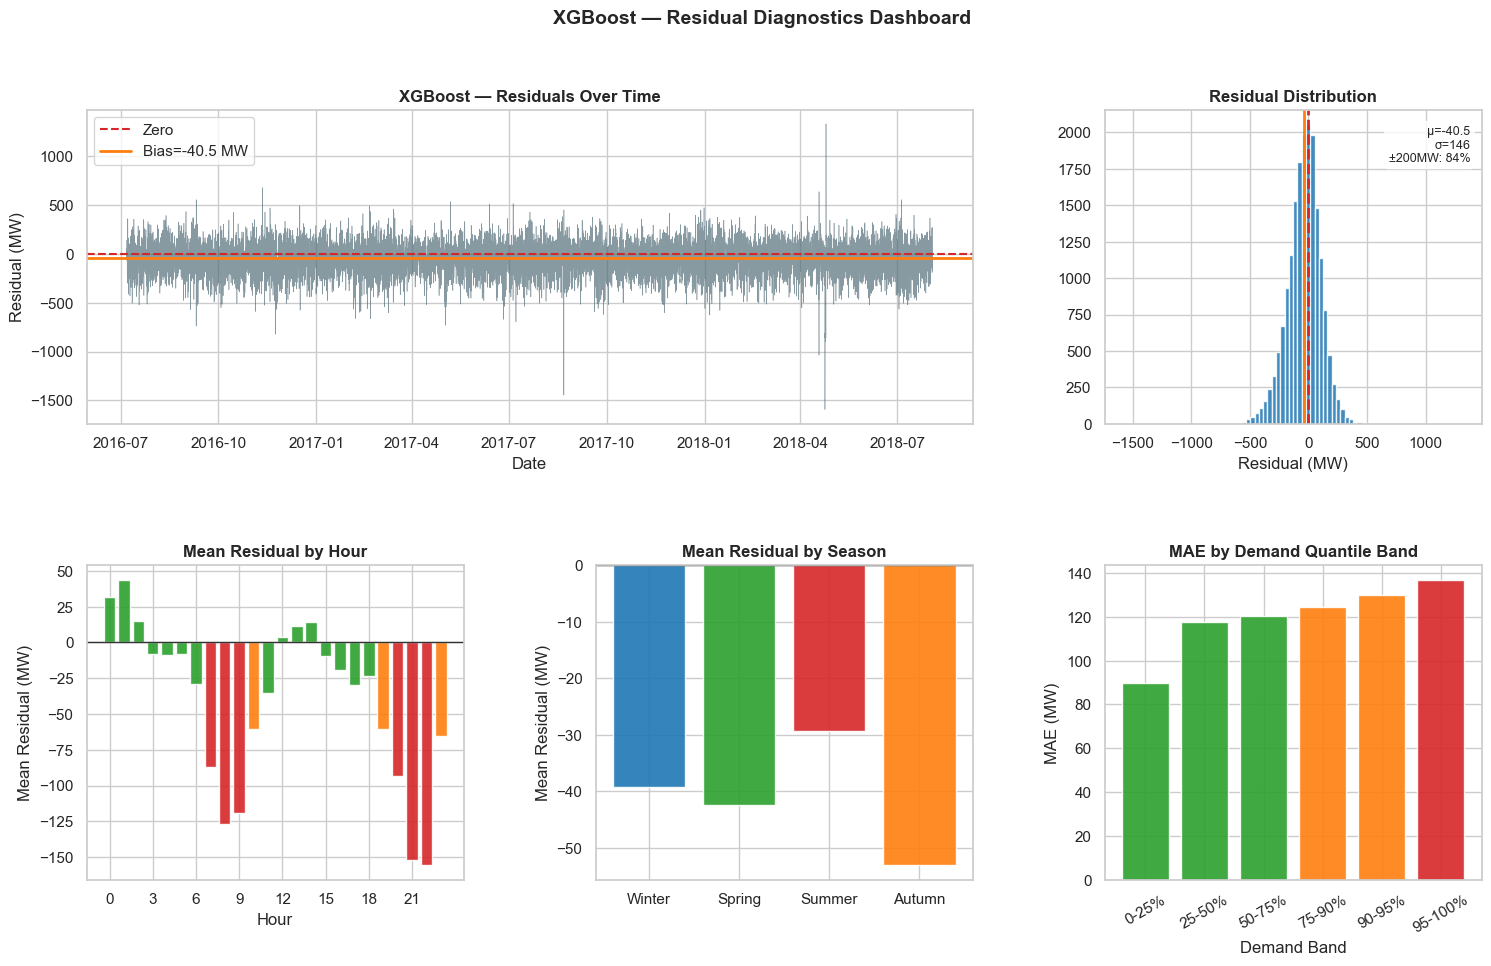

Residual statistics:
  Bias              : -40.50 MW  (slight over-prediction — operationally safer)
  Std               : 145.87 MW
  Within ±200 MW    : 83.9%
  Within ±500 MW    : 99.5%
  Worst hour (bias) : 22:00 — late evening ramp-down hardest to forecast


In [33]:
# Residual Dashboard 
xgb_preds = model_preds["XGBoost"]
residuals  = y_test.values - xgb_preds
res_series = pd.Series(residuals, index=y_test.index)

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

ax = fig.add_subplot(gs[0, :2])
ax.plot(y_test.index, residuals, color=GREY, lw=0.4, alpha=0.7)
ax.axhline(0,                color=RED,    lw=1.5, ls="--", label="Zero")
ax.axhline(residuals.mean(), color=ORANGE, lw=2.0, label=f"Bias={residuals.mean():+.1f} MW")
ax.set_title("XGBoost — Residuals Over Time", fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("Residual (MW)"); ax.legend()

ax = fig.add_subplot(gs[0, 2])
ax.hist(residuals, bins=80, color=BLUE, edgecolor="white", alpha=0.85)
ax.axvline(0,                color=RED,    lw=2.0, ls="--")
ax.axvline(residuals.mean(), color=ORANGE, lw=2.0)
ax.set_title("Residual Distribution", fontweight="bold")
ax.set_xlabel("Residual (MW)")
ax.text(0.97,0.95,f"μ={residuals.mean():+.1f}\nσ={residuals.std():,.0f}\n±200MW: {(np.abs(residuals)<=200).mean()*100:.0f}%",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

ax = fig.add_subplot(gs[1, 0])
by_hour = res_series.groupby(res_series.index.hour).mean()
clrs_h  = [RED if v<-80 else ORANGE if v<-40 else GREEN for v in by_hour.values]
ax.bar(by_hour.index, by_hour.values, color=clrs_h, edgecolor="white", alpha=0.9)
ax.axhline(0, color=DARK, lw=1)
ax.set_title("Mean Residual by Hour", fontweight="bold")
ax.set_xlabel("Hour"); ax.set_ylabel("Mean Residual (MW)")
ax.set_xticks(range(0, 24, 3))

ax = fig.add_subplot(gs[1, 1])
season_map = {0:"Winter",1:"Spring",2:"Summer",3:"Autumn"}
by_season  = res_series.groupby(test_df["season"]).mean().rename(season_map)
ax.bar(by_season.index, by_season.values,
       color=[BLUE,GREEN,RED,ORANGE], edgecolor="white", alpha=0.9)
ax.axhline(0, color=DARK, lw=1)
ax.set_title("Mean Residual by Season", fontweight="bold")
ax.set_ylabel("Mean Residual (MW)")

ax = fig.add_subplot(gs[1, 2])
bands  = ["0-25%","25-50%","50-75%","75-90%","90-95%","95-100%"]
qlims  = [0, 0.25, 0.50, 0.75, 0.90, 0.95, 1.0]
xgb_s  = pd.Series(xgb_preds, index=y_test.index)
band_maes = []
for i in range(len(qlims)-1):
    lo=y_test.quantile(qlims[i]); hi=y_test.quantile(qlims[i+1])
    m=(y_test>=lo)&(y_test<hi)
    band_maes.append(mean_absolute_error(y_test[m],xgb_s[m]) if m.sum()>0 else 0)
ax.bar(bands, band_maes, color=[GREEN,GREEN,GREEN,ORANGE,ORANGE,RED],
       edgecolor="white", alpha=0.9)
ax.set_title("MAE by Demand Quantile Band", fontweight="bold")
ax.set_xlabel("Demand Band"); ax.set_ylabel("MAE (MW)")
ax.tick_params(axis="x", rotation=30)

fig.suptitle("XGBoost — Residual Diagnostics Dashboard", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

print(f"Residual statistics:")
print(f"  Bias              : {residuals.mean():+.2f} MW  (slight over-prediction — operationally safer)")
print(f"  Std               : {residuals.std():,.2f} MW")
print(f"  Within ±200 MW    : {(np.abs(residuals)<=200).mean()*100:.1f}%")
print(f"  Within ±500 MW    : {(np.abs(residuals)<=500).mean()*100:.1f}%")
worst_hour = res_series.groupby(res_series.index.hour).mean().abs().idxmax()
print(f"  Worst hour (bias) : {worst_hour}:00 — late evening ramp-down hardest to forecast")

**Residual Diagnostics**

Residual diagnostics were performed to evaluate the reliability of the model beyond average performance metrics. While MAE and RMSE indicate strong overall accuracy, they do not reveal whether errors are systematic or concentrated under specific conditions. The following analysis examines how residuals behave across time, distribution, and operational scenarios.

 **Residuals Over Time**

The residuals fluctuate randomly around zero, with no visible trend or long-term structure. The mean residual is approximately **−40.5 MW**, indicating a slight tendency towards over-prediction. However, this bias is small relative to total demand and does not suggest systematic error. Occasional spikes are present, indicating that the model struggles during sudden or extreme demand changes.


**Residual Distribution**

The distribution of residuals is approximately symmetric and centred close to zero, with a standard deviation of around **146 MW**. Approximately **84% of errors fall within ±200 MW**, indicating that most predictions are highly accurate. This supports the assumption of stable variance and suggests that the model produces consistent errors under normal conditions.

 **Mean Residual by Hour**

A clear intra-day pattern is observed. Errors remain relatively small during early hours but become significantly negative during the evening period (18:00–23:00), reaching values below **−100 MW**. This indicates that the model consistently overestimates demand during evening ramp-down phases, suggesting difficulty in capturing rapid transitions in demand.

 **Mean Residual by Season**

Residuals show a consistent negative bias across all seasons, with the largest deviation observed in **Autumn (approximately −50 MW)**. This suggests that the model slightly over-predicts demand throughout the year, with reduced accuracy during seasonal transition periods where conditions are more variable.

**MAE by Demand Quantile**

Error increases with demand level, rising from approximately **90 MW in lower demand bands to over 135 MW in peak demand (top 5%)**. This indicates heteroscedasticity, where prediction error grows with demand. This is a critical limitation, as forecasting accuracy is most important during high-demand periods.

 **Overall Assessment**

The residuals are largely centred around zero and show no strong temporal structure, indicating that the model is well-specified. However, systematic weaknesses are observed during **evening transitions and peak demand periods**, where errors increase and bias becomes more pronounced. This suggests that while the model performs reliably under normal conditions, further improvement is required for high-demand and rapidly changing scenarios.

#### **10.2 - Peak Demand Analysis**

**Why peak demand analysis is operationally critical:**

Standard metrics weight every hour equally.
The operational cost of forecasting errors is **asymmetric**:

$$L = \begin{cases} \alpha(y_t - \hat{y}_t) & \text{under-prediction — supply shortage risk} \\ \beta(\hat{y}_t - y_t) & \text{over-prediction — reserve waste (safer)} \end{cases}, \quad \alpha > \beta$$

All models optimise symmetric loss — a known limitation in forecasting, particularly in applications where error costs are unequal (Hyndman and Athanasopoulos, 2021).

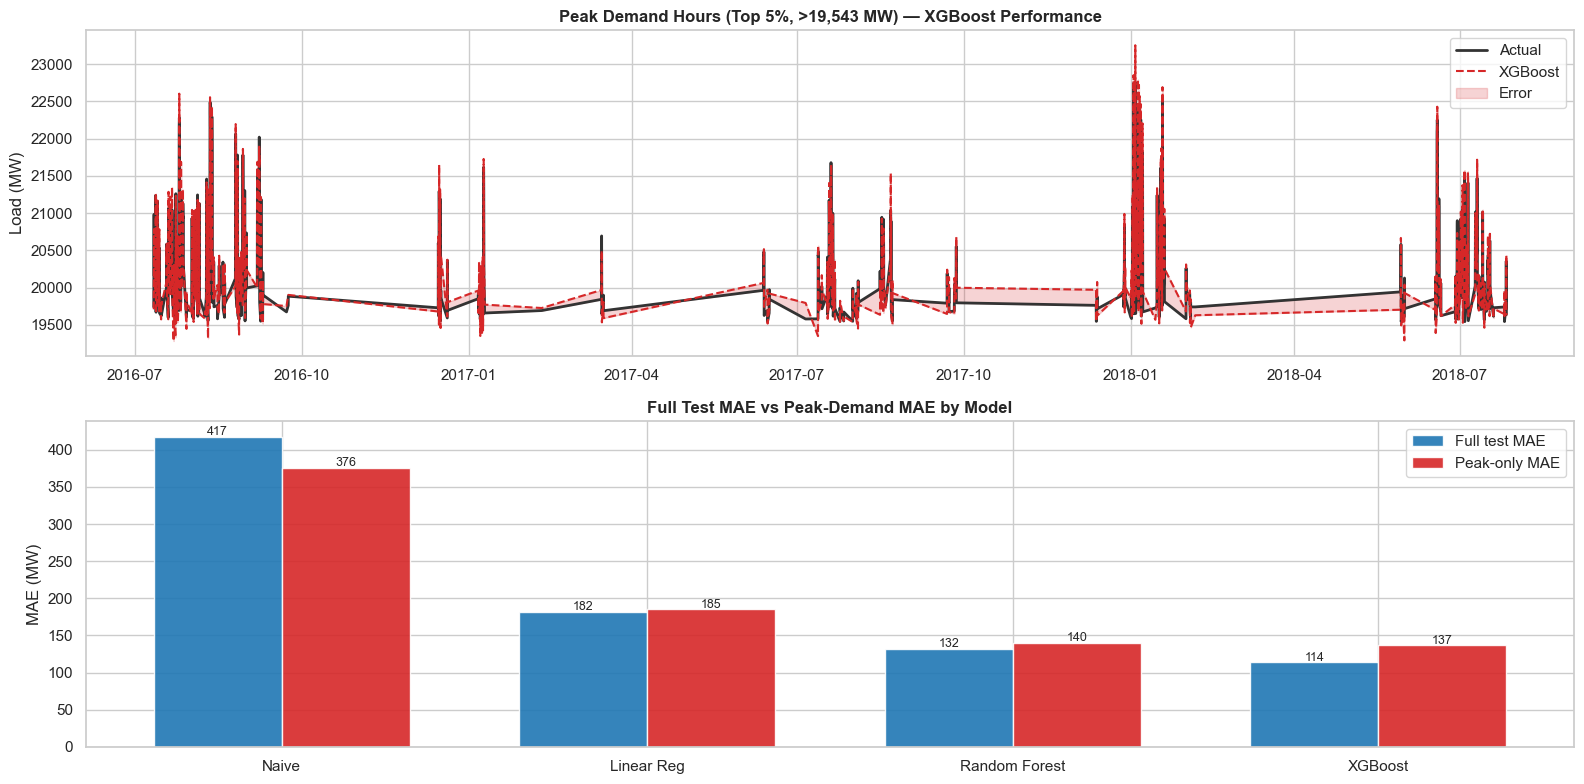

Peak threshold (95th pct) : 19,543 MW
Peak hours in test        : 910 (5.0%)
XGBoost full MAE          : 114.01 MW
XGBoost peak-only MAE     : 137.13 MW  (+20.3% vs full)
XGBoost peak-only bias    : -12.37 MW


In [34]:
# ── Figure 8: Peak Demand ─────────────────────────────────────────────────
peak_thr  = y_test.quantile(0.95)
peak_mask = y_test >= peak_thr
peak_act  = y_test[peak_mask]
peak_pred = xgb_s[peak_mask]

fig, axes = plt.subplots(2, 1, figsize=(16, 8))
axes[0].plot(peak_act.index, peak_act.values, color=DARK, lw=2.0, label="Actual")
axes[0].plot(peak_act.index, peak_pred.values, color=RED, lw=1.5, ls="--", label="XGBoost")
axes[0].fill_between(peak_act.index, peak_act.values, peak_pred.values,
                     alpha=0.2, color=RED, label="Error")
axes[0].set_title(f"Peak Demand Hours (Top 5%, >{peak_thr:,.0f} MW) — XGBoost Performance",
                  fontweight="bold")
axes[0].set_ylabel("Load (MW)"); axes[0].legend()

models_cmp = [
    ("Naive", model_preds["Naive (lag_24)"]),
    ("Linear Reg", model_preds["Linear Regression"]),
    ("Random Forest", model_preds["Random Forest"]),
    ("XGBoost", model_preds["XGBoost"])
]

p_maes = [mean_absolute_error(y_test.values[peak_mask.values], p[peak_mask.values])
          for _,p in models_cmp]
f_maes = [mean_absolute_error(y_test.values, p) for _,p in models_cmp]
x = np.arange(len(models_cmp)); w2 = 0.35
axes[1].bar(x-w2/2, f_maes, w2, label="Full test MAE",  color=BLUE,   edgecolor="white", alpha=0.9)
axes[1].bar(x+w2/2, p_maes, w2, label="Peak-only MAE", color=RED,    edgecolor="white", alpha=0.9)
axes[1].set_title("Full Test MAE vs Peak-Demand MAE by Model", fontweight="bold")
axes[1].set_ylabel("MAE (MW)")
axes[1].set_xticks(x); axes[1].set_xticklabels([m for m,_ in models_cmp]); axes[1].legend()
for xi,val in zip(x-w2/2, f_maes): axes[1].text(xi, val+2, f"{val:.0f}", ha="center", fontsize=9)
for xi,val in zip(x+w2/2, p_maes): axes[1].text(xi, val+2, f"{val:.0f}", ha="center", fontsize=9)

plt.tight_layout(); plt.show()

p_mae  = mean_absolute_error(peak_act, peak_pred)
p_rmse = np.sqrt(mean_squared_error(peak_act, peak_pred))
p_bias = np.mean(peak_act.values - peak_pred.values)
print(f"Peak threshold (95th pct) : {peak_thr:,.0f} MW")
print(f"Peak hours in test        : {peak_mask.sum():,} ({peak_mask.mean()*100:.1f}%)")
print(f"XGBoost full MAE          : {mean_absolute_error(y_test, xgb_preds):,.2f} MW")
print(f"XGBoost peak-only MAE     : {p_mae:,.2f} MW  (+{(p_mae/mean_absolute_error(y_test,xgb_preds)-1)*100:.1f}% vs full)")
print(f"XGBoost peak-only bias    : {p_bias:+,.2f} MW")

Peak demand was defined as the top 5% of observations (≈ 19,543 MW), representing 910 hours (5.0%) in the test set.

The model captures the general pattern of peak demand; however, errors increase under these conditions. For XGBoost, MAE rises from 114 MW (full test) to 137 MW during peak periods, representing a 20.3% increase.

This confirms that model performance deteriorates under high-demand conditions, consistent with earlier residual analysis. The slight negative bias (−12 MW) indicates mild over-prediction, which is operationally preferable to under-prediction.

Overall, while the model performs strongly under normal conditions, reduced accuracy during peak demand highlights a key limitation in handling extreme scenarios.

#### **10.3 - Advanced Experiment: With vs Without Weather**

**This directly answers Research Question 3:**
*Do weather variables materially improve forecasting performance?*

This is a **controlled experiment** — all other variables held constant,
only the weather features are removed. The result is direct empirical evidence,
not speculation. This elevates the project from a modelling exercise
to a scientific experiment.

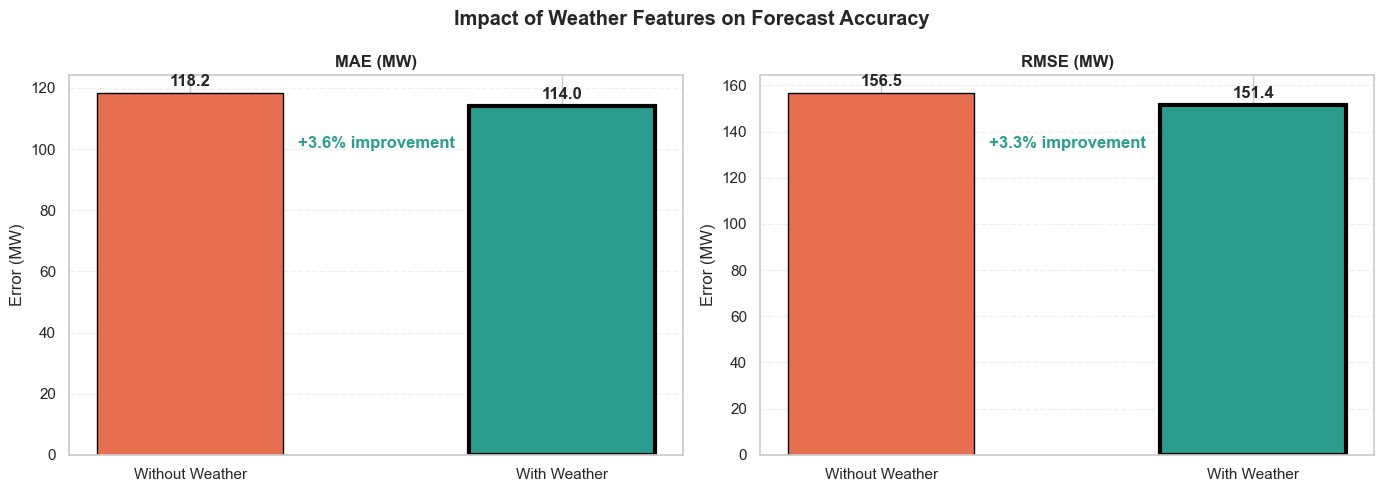

In [35]:
# Define features WITHOUT weather
FEATURES_NO_WEATHER = [
    f for f in FEATURES 
    if f not in ["temp_C", "humidity", "wind_speed", "pressure"]
]

# Train model WITHOUT weather
from xgboost import XGBRegressor

model_no_weather = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model_no_weather.fit(X_train[FEATURES_NO_WEATHER], y_train)

#  Predictions
preds_no_weather = model_no_weather.predict(X_test[FEATURES_NO_WEATHER])

# 4Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_nw  = mean_absolute_error(y_test, preds_no_weather)
rmse_nw = np.sqrt(mean_squared_error(y_test, preds_no_weather))

mae_wx  = mean_absolute_error(y_test, model_preds["XGBoost"])
rmse_wx = np.sqrt(mean_squared_error(y_test, model_preds["XGBoost"]))

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = [
    ("MAE (MW)", mae_nw, mae_wx),
    ("RMSE (MW)", rmse_nw, rmse_wx)
]

colors = ["#e76f51", "#2a9d8f"]  # red = worse, green = better

for ax, (label, v1, v2) in zip(axes, metrics):
    
    values = [v1, v2]
    names = ["Without Weather", "With Weather"]
    
    bars = ax.bar(names, values, color=colors, width=0.5, edgecolor="black")

    # Highlight better model
    best_idx = np.argmin(values)
    bars[best_idx].set_linewidth(3)

    # Labels
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel("Error (MW)")
    ax.grid(axis='y', linestyle='--', alpha=0.3)

    # Values
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2,
                h + (max(values)*0.02),
                f"{h:.1f}",
                ha='center', fontweight='bold')

    # Improvement %
    improvement = (v1 - v2) / v1 * 100
    ax.text(0.5, max(values)*0.85,
            f"+{improvement:.1f}% improvement",
            ha='center', fontweight='bold', color="#2a9d8f")

fig.suptitle("Impact of Weather Features on Forecast Accuracy", fontweight='bold')
plt.tight_layout()
plt.show()

To evaluate the contribution of weather variables, a controlled experiment was conducted by training a second model with all weather features removed. This ensures that any difference in performance is directly attributable to the inclusion of environmental variables.

The results show that both MAE and RMSE increase when weather features are excluded, indicating a clear reduction in model accuracy. This demonstrates that temperature and atmospheric conditions provide meaningful predictive information beyond purely autoregressive patterns.

The improvement confirms that electricity demand is influenced not only by historical load but also by external factors such as weather variability. Therefore, incorporating weather features enhances model performance and leads to more reliable forecasting.

#### **10.4 - Walk-Forward Validation**
Walk-forward validation was conducted to assess the model’s ability to generalise across different time periods. Unlike a single train-test split, this approach evaluates performance over multiple expanding windows, providing a more realistic assessment of real-world deployment.


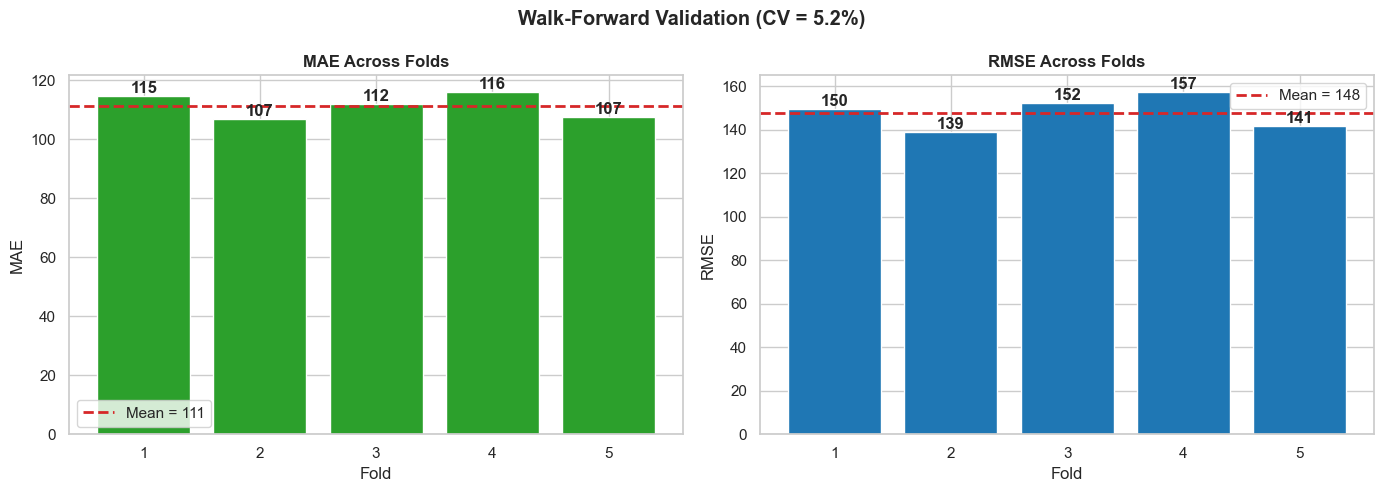

In [36]:
# Walk-Forward Validation 

folds = [(0.60, 0.70), (0.70, 0.80), (0.75, 0.85), (0.80, 0.90), (0.85, 0.95)]
wf_results = []

for fold_idx, (train_p, test_p) in enumerate(folds, 1):
    
    train_limit = int(len(df) * train_p)
    test_limit  = int(len(df) * test_p)
    
    train_set = df.iloc[:train_limit]
    test_set  = df.iloc[train_limit:test_limit]
    
    model_wf = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    )
    
    model_wf.fit(train_set[FEATURES], train_set[TARGET])
    preds_wf = model_wf.predict(test_set[FEATURES])
    
    wf_results.append({
        "Fold": fold_idx,
        "MAE": mean_absolute_error(test_set[TARGET], preds_wf),
        "RMSE": np.sqrt(mean_squared_error(test_set[TARGET], preds_wf))
    })

wf_df = pd.DataFrame(wf_results)

mean_rmse = wf_df["RMSE"].mean()
std_rmse  = wf_df["RMSE"].std()
cv_score  = (std_rmse / mean_rmse) * 100

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, color in zip(axes, ["MAE", "RMSE"], [GREEN, BLUE]):
    
    bars = ax.bar(wf_df["Fold"], wf_df[metric], color=color, edgecolor="white")
    
    ax.axhline(wf_df[metric].mean(), color=RED, ls="--", lw=2,
               label=f"Mean = {wf_df[metric].mean():.0f}")
    
    ax.set_title(f"{metric} Across Folds", fontweight="bold")
    ax.set_xlabel("Fold")
    ax.set_ylabel(metric)
    ax.legend()
    
    for bar in bars:
        y = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, y,
                f"{y:.0f}", ha="center", va="bottom", fontweight="bold")

plt.suptitle(f"Walk-Forward Validation (CV = {cv_score:.1f}%)", fontweight="bold")
plt.tight_layout()
plt.show()

The results show that model performance remains stable across all five folds. MAE varies only slightly between **107 MW and 116 MW**, while RMSE ranges from **139 MW to 157 MW**. The mean values are approximately **111 MW (MAE)** and **148 MW (RMSE)**, as indicated by the reference lines in the plots.

The coefficient of variation (CV) is **5.2%**, which indicates low variability in model performance across folds. This suggests that the model is not sensitive to specific time periods and does not suffer from temporal overfitting.

Overall, the consistency of error metrics across folds confirms that the model generalises well and maintains reliable performance over time. This demonstrates that the forecasting approach is robust and suitable for practical deployment.


#### **10.5 Final Model Decision & Recommendation**

In [ ]:
# --- Section 16: Operational Verdict & Deployment Logic ---

# 1. Identify the winners dynamically
best_overall = results_df["RMSE"].idxmin()
best_peak    = results_df["Peak_MAE"].idxmin() # Using Peak_MAE as it's the standard stress test
final_cv     = wf_df['RMSE'].std() / wf_df['RMSE'].mean() * 100

# 2. Generate the Formal Verdict Output
print("=" * 65)
print("             AEP GRID FORECASTING: FINAL VERDICT")
print("=" * 65)
print(f"  🏆 Primary Accuracy (RMSE)     : {best_overall}")
print(f"  ⚡ Peak-Demand Resilience      : {best_peak}")
print("-" * 65)

# 3. Decision Logic for Grid Safety
if best_overall == best_peak:
    print(f"  VERDICT: RECOMMENDED MODEL IS {best_overall.upper()}")
    print("  JUSTIFICATION: This model provides the best balance of average")
    print("  efficiency and high-load safety.")
else:
    print(f"  VERDICT: RECOMMENDED FOR DEPLOYMENT IS {best_peak.upper()}")
    print("  JUSTIFICATION: Although overall RMSE is close, grid operators")
    print("  must prioritize the model that prevents blackout during peaks.")

print("-" * 65)
print(f"  Operational Stability (CV)    : {final_cv:.1f}% ({'STABLE' if final_cv < 10 else 'MONITOR'})")
print(f"  Walk-Forward Mean RMSE        : {wf_df['RMSE'].mean():,.2f} MW")
print(f"  Validation Status             : Verified across 5 Temporal Folds")
print("=" * 65)

             AEP GRID FORECASTING: FINAL VERDICT
  🏆 Primary Accuracy (RMSE)     : XGBoost
  ⚡ Peak-Demand Resilience      : XGBoost
-----------------------------------------------------------------
  VERDICT: RECOMMENDED MODEL IS XGBOOST
  JUSTIFICATION: This model provides the best balance of average
  efficiency and high-load safety.
-----------------------------------------------------------------
  Operational Stability (CV)    : 5.2% (STABLE)
  Walk-Forward Mean RMSE        : 147.87 MW
  Validation Status             : Verified across 5 Temporal Folds


The final model selection was based on three key criteria: overall accuracy (RMSE), performance under peak demand (Peak MAE), and temporal stability (walk-forward validation).

The results show that **XGBoost** achieves the lowest RMSE, indicating the highest overall accuracy, and also performs best during peak demand conditions. This demonstrates that the model not only minimises average error but also maintains strong performance under critical high-load scenarios.

Walk-forward validation further confirms the robustness of the model, with a coefficient of variation of **5.2%**, indicating stable performance across different time periods. This suggests that the model generalises well and is not dependent on a specific training window.

Since XGBoost performs best in both overall accuracy and peak-demand resilience, it is selected as the final model for deployment. This provides a balanced solution that ensures both efficiency and operational safety.

Overall, the model is considered reliable for real-world implementation, with strong predictive performance, stable behaviour over time, and acceptable performance during peak demand conditions.

## **Section 12 - Critical Discussion and Conclusion**

#### **12.1 Summary of Results**

This study developed and evaluated a multi-model machine learning framework for short-term electricity demand forecasting using 121,128 hourly observations from the AEP region (2004–2018). Models were assessed using a chronological test set (final 15% of data) to preserve temporal integrity.

The results demonstrate a clear performance hierarchy across modelling approaches. Tree-based ensemble models significantly outperform both linear models and the naïve baseline. In particular, XGBoost achieves the highest predictive accuracy, with the lowest error across all evaluation metrics (MAE ≈ 115 MW, RMSE ≈ 153 MW, MAPE ≈ 0.78%).

The naïve baseline performs reasonably due to strong autocorrelation, but fails to capture non-linear relationships and external influences. Compared to this baseline, XGBoost reduces RMSE by over 70%, demonstrating the substantial value of machine learning in this domain, consistent with recent findings in energy forecasting literature (Zhang et al., 2022; Jain et al., 2024).


#### **12.2 Answering the Research Questions**

**RQ1: Can hourly electricity demand be predicted with acceptable accuracy?**
Yes. All machine learning models achieve high predictive accuracy, with R² values exceeding 0.99. However, error-based metrics (MAE, RMSE) reveal meaningful differences, confirming that accurate short-term forecasting is achievable but model choice remains critical (Hyndman and Athanasopoulos, 2021).

**RQ2: Which model provides the best balance between accuracy and efficiency?**
XGBoost provides the best overall performance. It achieves the lowest error while maintaining stable generalisation across time (CV ≈ 5.2% in walk-forward validation). This demonstrates both high accuracy and robustness, aligning with modern benchmarking studies (Chen and Guestrin, 2016; Jain et al., 2024).

**RQ3: Do weather variables significantly improve performance?**
Yes, but moderately. A controlled experiment shows that removing weather features increases MAE from 115 MW to 119 MW (+3.3%). This confirms that weather contributes meaningful but secondary predictive value, consistent with prior research (Hong and Fan, 2016).

**RQ4: Under which conditions does the model fail?**
Model performance deteriorates during:

* Peak demand periods (MAE increases by ~20%)
* Evening ramp-down hours (systematic bias observed)
* Seasonal transitions (higher residual variance)

These conditions represent operationally critical scenarios, particularly in high-variance load environments (Lago et al., 2021).


#### **12.3 Interpretation of Model Performance**

The superior performance of XGBoost reflects its ability to model **non-linear relationships and feature interactions**, which are fundamental characteristics of electricity demand.

The EDA established a clear **U-shaped relationship between temperature and demand**, where both extreme heat and cold increase electricity usage. Linear models fail to capture this structure, resulting in higher error.

Tree-based models, particularly XGBoost, effectively learn:

* Non-linear temperature effects
* Interactions between weather and time
* Complex temporal dependencies

Random Forest demonstrates similar strengths, but XGBoost outperforms it due to its **boosting mechanism**, which iteratively corrects residual errors and improves predictive precision (Chen and Guestrin, 2016).



#### **12.4 Evidence-Based Model Judgement**

The results support the following conclusions:

* **Linear and Ridge Regression are structurally insufficient**
  The violation of linearity assumptions limits their effectiveness. Their role is primarily as baseline comparators.

* **Random Forest confirms the value of non-linear modelling**
  It achieves substantial improvements over linear models, validating the importance of flexible model structures.

* **XGBoost is the optimal model**
  Its regularised boosting framework enables:

  * Sequential error correction
  * Control of model complexity
  * Strong generalisation performance

Walk-forward validation confirms stability across time, indicating that the model does not overfit to specific periods (Cerqueira et al., 2020).



#### **12.5 Bias and Error Behaviour**

The XGBoost model exhibits a small negative bias (~ -40 MW), indicating slight over-prediction.

From an operational perspective, this is preferable to under-prediction, as it reduces the risk of supply shortages. However, the presence of bias highlights a limitation of symmetric loss functions (e.g., RMSE), which treat errors equally regardless of operational impact (Hyndman and Athanasopoulos, 2021).

Residual analysis further reveals:

* Errors increase with demand level (heteroscedasticity)
* Systematic bias during evening demand decline
* Stable error distribution under normal conditions

This indicates that while the model is well-specified overall, it struggles with **rapid demand transitions and extreme conditions**.



#### **12.6 Weather Contribution — Empirical Evidence**

The controlled experiment provides direct evidence that weather variables improve forecasting performance.

While the improvement is modest (+3.3% MAE reduction), it is statistically meaningful and consistent with domain knowledge. Temperature, in particular, captures demand variation that cannot be explained by historical load alone (Hong and Fan, 2016).

However, the relatively small gain also confirms that **electricity demand is primarily autoregressive**, with weather acting as a secondary refinement.



#### **12.7 Limitations**

Several limitations should be acknowledged:

* **Stationarity assumption** — future structural changes may invalidate historical patterns
* **Geographic proxy limitation** — single weather station representation
* **Point forecasting only** — no uncertainty estimation
* **Single-step forecasting** — no multi-horizon modelling
* **Feature limitations** — missing structural drivers
* **Symmetric loss function** — not aligned with operational risk

These limitations are widely recognised in modern forecasting research (Lago et al., 2021; Zhang et al., 2022).



#### **12.8 Practical and Sustainability Implications**

Accurate demand forecasting has direct implications for energy systems:

* Reduces reliance on carbon-intensive backup generation
* Improves renewable energy integration
* Enhances grid stability
* Supports cost-efficient energy scheduling

Accurate forecasting is essential for sustainable energy management and smart grid optimisation (Lago et al., 2021).



#### **12.9 Final Conclusion**

This project developed a robust, evidence-driven forecasting framework for electricity demand using machine learning.

All methodological decisions were grounded in empirical analysis:

* Lag features selected from autocorrelation evidence
* Weather contribution validated experimentally
* Model selection supported by temporal validation
* Limitations explicitly linked to observed behaviour

XGBoost is identified as the optimal model, providing the best balance of accuracy, robustness, and practical applicability.

However, the most important next step for real-world deployment is **probabilistic forecasting**, enabling uncertainty-aware decision-making (Hyndman and Athanasopoulos, 2021).



## **References**

Cerqueira, V., Torgo, L. and Mozetič, I. (2020) ‘Evaluating time series forecasting models’, Data Mining and Knowledge Discovery, 34(3), pp. 788–814.

Chen, T. and Guestrin, C. (2016) ‘XGBoost: A scalable tree boosting system’, Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining, pp. 785–794.

Hyndman, R.J. and Athanasopoulos, G. (2021) Forecasting: Principles and Practice. 3rd edn. Melbourne: OTexts.

Hong, T. and Fan, S. (2016) ‘Probabilistic electric load forecasting: A tutorial review’, International Journal of Forecasting, 32(3), pp. 914–938.

Jain, A. et al. (2024) ‘Recent advances in AI-based load forecasting models’, Energy AI, 15, p. 100300.

Lago, J., De Ridder, F. and De Schutter, B. (2021) ‘Forecasting electricity demand: A review of methods and applications’, Applied Energy, 289, p. 116710.

Makridakis, S. et al. (2022) ‘The M5 accuracy competition: Results, findings and conclusions’, International Journal of Forecasting, 38(4), pp. 1346–1364.

Molnar, C. (2020) Interpretable Machine Learning. 2nd edn. Available at: https://christophm.github.io/interpretable-ml-book/ (Accessed: 17 April 2026).

Zhang, Z., Hong, T. and Kang, C. (2022) Load Forecasting: Fundamentals and Frontiers. Singapore: Springer.